# K-means Downgrade Prediction
Повторяет всю логику `segment overflows.ipynb`, заменяя RFM-сегменты кластерами K-means.

**Структура:**
1. Загрузка данных
2. Обучение K-means на Q1 2017 + ранжирование кластеров
3. Применение модели ко всем кварталам
4. Панель переходов + метка downgrade
5. Markov + Bayesian baseline
6. Бинарные классификаторы
7. Survival analysis
8. Business application (Early Warning System)
9. SHAP
10. Сравнение с RFM (Cohen's Kappa)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.cluster import KMeans

# --- Константы ---
N_CLUSTERS   = 10
RANDOM_STATE = 42

# Веса для ранжирования кластеров
RANK_WEIGHTS = {
    'avg_order_value': 0.35,
    'margin':          0.30,
    'delivered_ratio': 0.22,
    'cancel_ratio':    0.13,   # инвертировано: меньше = лучше
}

os.makedirs('models', exist_ok=True)
print('Setup done. N_CLUSTERS =', N_CLUSTERS)

Setup done. N_CLUSTERS = 10


## 1. Загрузка данных

In [2]:
df = pd.read_csv('data/client_pivot_quarter.csv')
df['quarter'] = pd.PeriodIndex(df['quarter'], freq='Q')
print(df.shape)
print(df['quarter'].value_counts().sort_index())
df.head(2)

(368032, 37)
quarter
2017Q1    102786
2017Q2    102435
2017Q3    113587
2017Q4     49224
Freq: Q-DEC, Name: count, dtype: int64


,Телефон_new,quarter,total_orders,delivered_ratio,items,most_freq_order_size,cancel_ratio,return_ratio,revenue,margin,...,FAR EAST,NORTH,PRIVOLZIE,SIBERIA,SOUTHERN,URAL,delivery_pick point,delivery_курьерская,delivery_самовывоз,payment_безналичная
0,55575048-54555048485775,2017Q3,6,0.333333,224,4,0.666667,0.0,310425.0,14935.28,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,1.000000
1,55574953-48485556555475,2017Q2,9,1.000000,1140,20,0.111111,0.0,294810.0,22829.77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.222222,0.0,0.777778


In [3]:
# Столбцы для K-means
HEAVY_TAIL = ['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size']
STANDARD_FEATS = ['delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days']
BASE_COLS = ['total_orders', 'days_since_first_purchase']
CATEGORY_COLS = [
    'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',
]
REGION_COLS  = ['CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL']
DELIVERY_COLS = ['delivery_pick point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная']
OTHER_COLS = BASE_COLS + CATEGORY_COLS + REGION_COLS + DELIVERY_COLS

KM_FEATURES = HEAVY_TAIL + STANDARD_FEATS + OTHER_COLS
print(f'K-means features: {len(KM_FEATURES)}')
print(KM_FEATURES)

K-means features: 35
['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size', 'delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days', 'total_orders', 'days_since_first_purchase', 'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА', 'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ', 'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ', 'CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL', 'delivery_pick point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная']


## 2. Обучение K-means на Q1 2017

In [4]:
df_q1 = df[df['quarter'] == '2017Q1'].copy()

# Сдвиг margin (чтобы всё > 0 для log1p)
margin_shift_km = float(-df_q1['margin'].min() + 1.0)
df_q1['margin'] = df_q1['margin'] + margin_shift_km

# log1p для heavy-tail
for col in HEAVY_TAIL:
    df_q1[col] = np.log1p(df_q1[col].clip(lower=0.0))

# Fit scalers на Q1
robust_sc = RobustScaler()
df_q1[HEAVY_TAIL] = robust_sc.fit_transform(df_q1[HEAVY_TAIL])

std_sc_feats = StandardScaler()
df_q1[STANDARD_FEATS] = std_sc_feats.fit_transform(df_q1[STANDARD_FEATS])

std_sc_other = StandardScaler()
df_q1[OTHER_COLS] = std_sc_other.fit_transform(df_q1[OTHER_COLS].fillna(0))

X_q1 = df_q1[KM_FEATURES].values

# Обучаем K-means
km = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
km.fit(X_q1)
print('K-means trained. Inertia:', round(km.inertia_, 1))

# Сохраняем
joblib.dump(km, 'models/kmeans_q1_2017.pkl')
joblib.dump({
    'margin_shift': margin_shift_km,
    'robust_sc':    robust_sc,
    'std_sc_feats': std_sc_feats,
    'std_sc_other': std_sc_other,
}, 'models/scalers_q1_2017.pkl')
print('Scalers saved.')

K-means trained. Inertia: 2525735.5
Scalers saved.


## 3. Применение K-means ко всем кварталам

In [5]:
def scale_quarter(df_q, margin_shift, robust_sc, std_sc_feats, std_sc_other):
    """Масштабирует данные квартала с помощью scalers, обученных на Q1."""
    d = df_q.copy()
    d['margin'] = (d['margin'] + margin_shift).clip(lower=0.0)
    for col in HEAVY_TAIL:
        d[col] = np.log1p(d[col].clip(lower=0.0))
    d[HEAVY_TAIL]    = robust_sc.transform(d[HEAVY_TAIL])
    d[STANDARD_FEATS] = std_sc_feats.transform(d[STANDARD_FEATS])
    d[OTHER_COLS]    = std_sc_other.transform(d[OTHER_COLS].fillna(0))
    return d

records = []
for q in sorted(df['quarter'].unique()):
    df_q   = df[df['quarter'] == q].copy()
    df_q_s = scale_quarter(df_q, margin_shift_km, robust_sc, std_sc_feats, std_sc_other)
    X_q    = df_q_s[KM_FEATURES].values
    cluster_ids = km.predict(X_q)
    tmp = df[df['quarter'] == q][['Телефон_new', 'quarter']].copy()
    tmp['cluster_id'] = cluster_ids
    records.append(tmp)

df_clustered = pd.concat(records, ignore_index=True)
print(df_clustered.shape)
print(df_clustered.groupby('quarter')['cluster_id'].value_counts().unstack().fillna(0).astype(int))

(368032, 3)
cluster_id      0      1    2      3     4      5      6     7      8     9
quarter                                                                    
2017Q1      23676  10647  474  11703  6253  11637  14351  6357  16517  1171
2017Q2      21624  10053  405  10118  6934  12446  13555  8393  17799  1108
2017Q3      24652  13400  334   2588  6152  13350  20223  9836  21573  1479
2017Q4      10764   7474   21    941  1733   4642  11085  2699   9113   752


## 4. Ранжирование кластеров по бизнес-метрикам (Q1 профили)

In [6]:
# Профили кластеров по исходным (нескалированным) данным Q1
df_q1_orig = df[df['quarter'] == '2017Q1'].copy()
df_q1_orig['cluster_id'] = km.labels_

cluster_profiles = df_q1_orig.groupby('cluster_id').agg(
    avg_order_value=('avg_order_value', 'median'),
    margin=('margin', 'median'),
    delivered_ratio=('delivered_ratio', 'mean'),
    cancel_ratio=('cancel_ratio', 'mean'),
    n_clients=('Телефон_new', 'count'),
).reset_index()

# Нормализация 0-1
for col in ['avg_order_value', 'margin', 'delivered_ratio']:
    mn, mx = cluster_profiles[col].min(), cluster_profiles[col].max()
    cluster_profiles[f'{col}_norm'] = (cluster_profiles[col] - mn) / (mx - mn + 1e-9)

# cancel_ratio: меньше = лучше → инвертируем
mn, mx = cluster_profiles['cancel_ratio'].min(), cluster_profiles['cancel_ratio'].max()
cluster_profiles['cancel_ratio_norm'] = 1 - (cluster_profiles['cancel_ratio'] - mn) / (mx - mn + 1e-9)

cluster_profiles['score'] = (
    RANK_WEIGHTS['avg_order_value'] * cluster_profiles['avg_order_value_norm'] +
    RANK_WEIGHTS['margin']          * cluster_profiles['margin_norm'] +
    RANK_WEIGHTS['delivered_ratio'] * cluster_profiles['delivered_ratio_norm'] +
    RANK_WEIGHTS['cancel_ratio']    * cluster_profiles['cancel_ratio_norm']
)

cluster_profiles = cluster_profiles.sort_values('score').reset_index(drop=True)
cluster_profiles['cluster_rank'] = range(len(cluster_profiles))  # 0 = худший, 9 = лучший

CLUSTER_RANK = dict(zip(cluster_profiles['cluster_id'], cluster_profiles['cluster_rank']))

print('Cluster rank mapping (id → rank):', CLUSTER_RANK)
print()
cluster_profiles[['cluster_id', 'cluster_rank', 'score', 'avg_order_value', 'margin',
                   'delivered_ratio', 'cancel_ratio', 'n_clients']].round(3)

Cluster rank mapping (id → rank): {7: 0, 2: 1, 3: 2, 9: 3, 6: 4, 0: 5, 8: 6, 1: 7, 5: 8, 4: 9}



,cluster_id,cluster_rank,score,avg_order_value,margin,delivered_ratio,cancel_ratio,n_clients
0,7,0,0.116,2017.50,486.400,0.486,0.120,6357
1,2,1,0.245,2125.75,415.420,0.904,0.189,474
2,3,2,0.249,1330.00,179.000,0.904,0.133,11703
3,9,3,0.325,1957.00,75.490,0.920,0.074,1171
4,6,4,0.330,3124.00,589.120,0.914,0.153,14351
5,0,5,0.357,1410.00,260.605,0.966,0.054,23676
6,8,6,0.359,1889.00,173.770,0.951,0.057,16517
7,1,7,0.398,2233.00,770.840,0.950,0.075,10647
8,5,8,0.448,2560.00,867.180,0.958,0.044,11637
9,4,9,0.955,10990.00,4242.000,0.929,0.075,6253


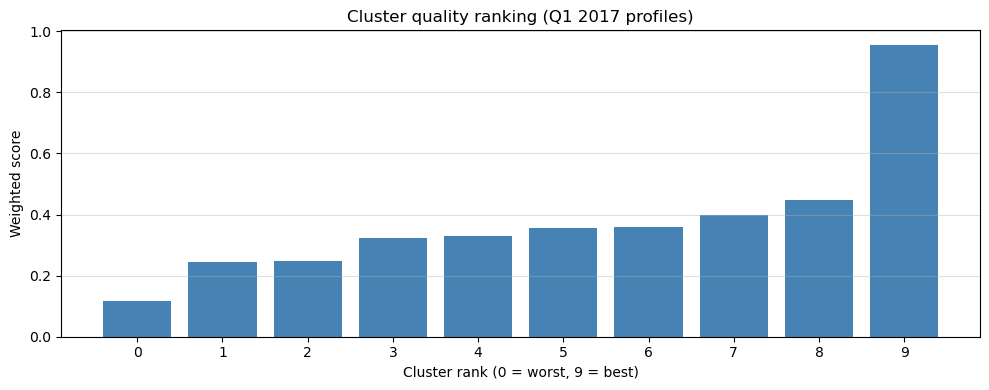

In [7]:
# Визуализация: score по кластерам
cp_plot = cluster_profiles.sort_values('cluster_rank')
plt.figure(figsize=(10, 4))
plt.bar(cp_plot['cluster_rank'], cp_plot['score'], color='steelblue')
plt.xlabel('Cluster rank (0 = worst, 9 = best)')
plt.ylabel('Weighted score')
plt.title('Cluster quality ranking (Q1 2017 profiles)')
plt.xticks(range(N_CLUSTERS))
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Панель переходов и метка downgrade

In [8]:
# Добавляем cluster_rank
df_clustered['cluster_rank'] = df_clustered['cluster_id'].map(CLUSTER_RANK)

# Объединяем с исходным датафреймом (признаки клиентов)
df_km = df.merge(
    df_clustered[['Телефон_new', 'quarter', 'cluster_id', 'cluster_rank']],
    on=['Телефон_new', 'quarter'], how='left'
)

df_km = df_km.sort_values(['Телефон_new', 'quarter'])
df_km['cluster_id_next']   = df_km.groupby('Телефон_new')['cluster_id'].shift(-1)
df_km['cluster_rank_next'] = df_km.groupby('Телефон_new')['cluster_rank'].shift(-1)

transitions = df_km.dropna(subset=['cluster_id_next']).copy()
transitions['downgrade'] = (transitions['cluster_rank_next'] < transitions['cluster_rank']).astype(int)

print('Transitions shape:', transitions.shape)
print('\nDowngrade rate by quarter:')
print(transitions.groupby('quarter')['downgrade'].mean().round(3))

Transitions shape: (79089, 42)

Downgrade rate by quarter:
quarter
2017Q1    0.301
2017Q2    0.291
2017Q3    0.222
Freq: Q-DEC, Name: downgrade, dtype: float64


In [9]:
# Train: Q1→Q2, Q2→Q3  |  Test: Q3→Q4
quarters_sorted = sorted(transitions['quarter'].unique())
train_quarters  = quarters_sorted[:2]   # Q1, Q2
test_quarters   = [quarters_sorted[2]]  # Q3

train_km = transitions[transitions['quarter'].isin(train_quarters)].copy()
test_km  = transitions[transitions['quarter'].isin(test_quarters)].copy()

# Сортируем по времени: Q1→Q2 строки идут первыми, Q2→Q3 — вторыми.
# Без этого PredefinedSplit работает по позиции, а не по кварталу.
train_km = train_km.sort_values('quarter').reset_index(drop=True)
test_km  = test_km.sort_values('quarter').reset_index(drop=True)

print(f'Train: {train_km.shape}  |  Test: {test_km.shape}')
print(f'Train downgrade rate: {train_km["downgrade"].mean():.3f}')
print(f'Test downgrade rate:  {test_km["downgrade"].mean():.3f}')

n_q1 = (train_km['quarter'] == train_quarters[0]).sum()
n_q2 = (train_km['quarter'] == train_quarters[1]).sum()
print(f'\nТрейн по кварталам: {train_quarters[0]}→next = {n_q1}, {train_quarters[1]}→next = {n_q2}')


Train: (63845, 42)  |  Test: (15244, 42)
Train downgrade rate: 0.296
Test downgrade rate:  0.222

Трейн по кварталам: 2017Q1→next = 35612, 2017Q2→next = 28233


## 6. Markov матрица переходов + Bayesian baseline

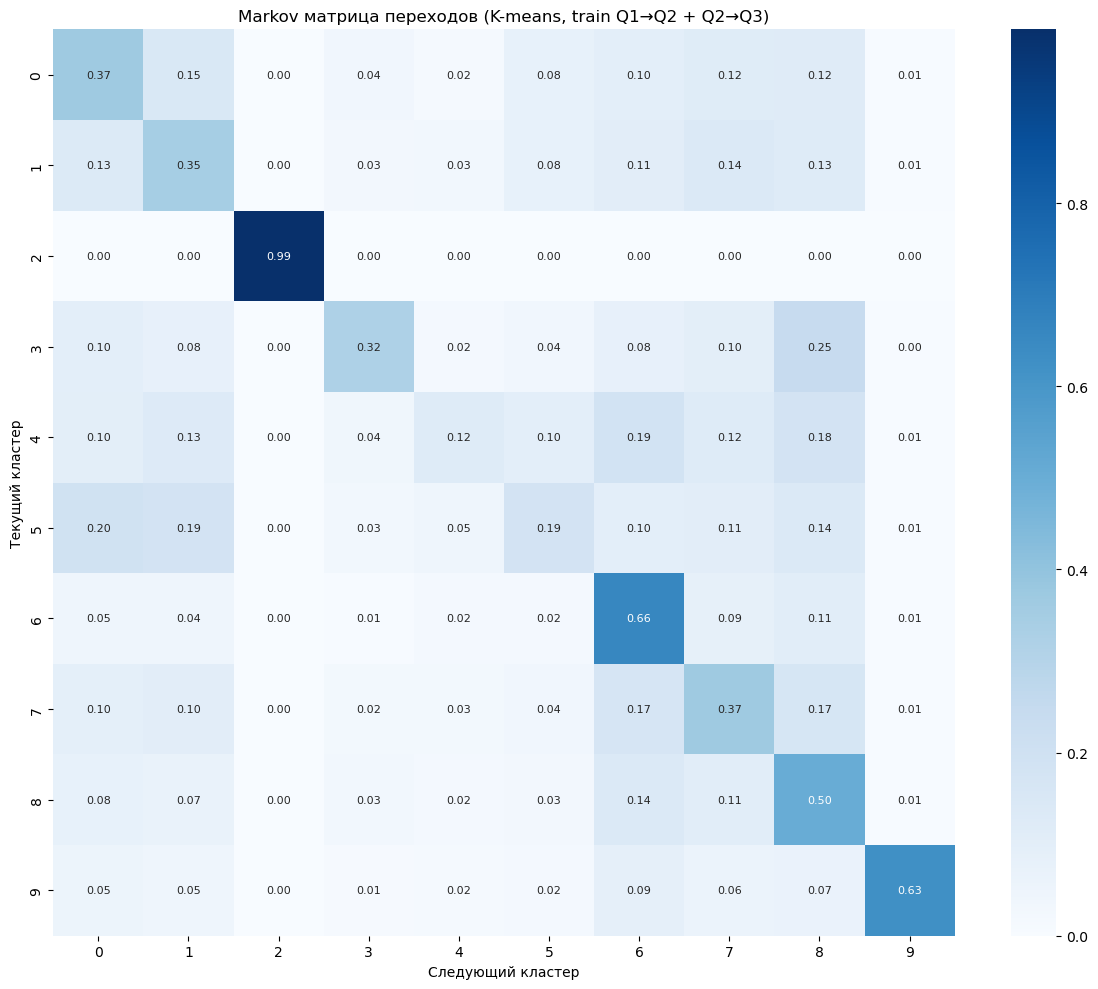

In [10]:
states = sorted(df_km['cluster_id'].dropna().unique().astype(int).tolist())

train_m = train_km.copy()
train_m['cluster_id']      = train_m['cluster_id'].astype(int)
train_m['cluster_id_next'] = train_m['cluster_id_next'].astype(int)

counts_km = pd.crosstab(train_m['cluster_id'], train_m['cluster_id_next'])
counts_km = counts_km.reindex(index=states, columns=states, fill_value=0)
P_km = counts_km.div(counts_km.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 10))
sns.heatmap(P_km, annot=True, cmap='Blues', fmt='.2f', annot_kws={'size': 8})
plt.title('Markov матрица переходов (K-means, train Q1→Q2 + Q2→Q3)')
plt.xlabel('Следующий кластер')
plt.ylabel('Текущий кластер')
plt.tight_layout()
plt.show()

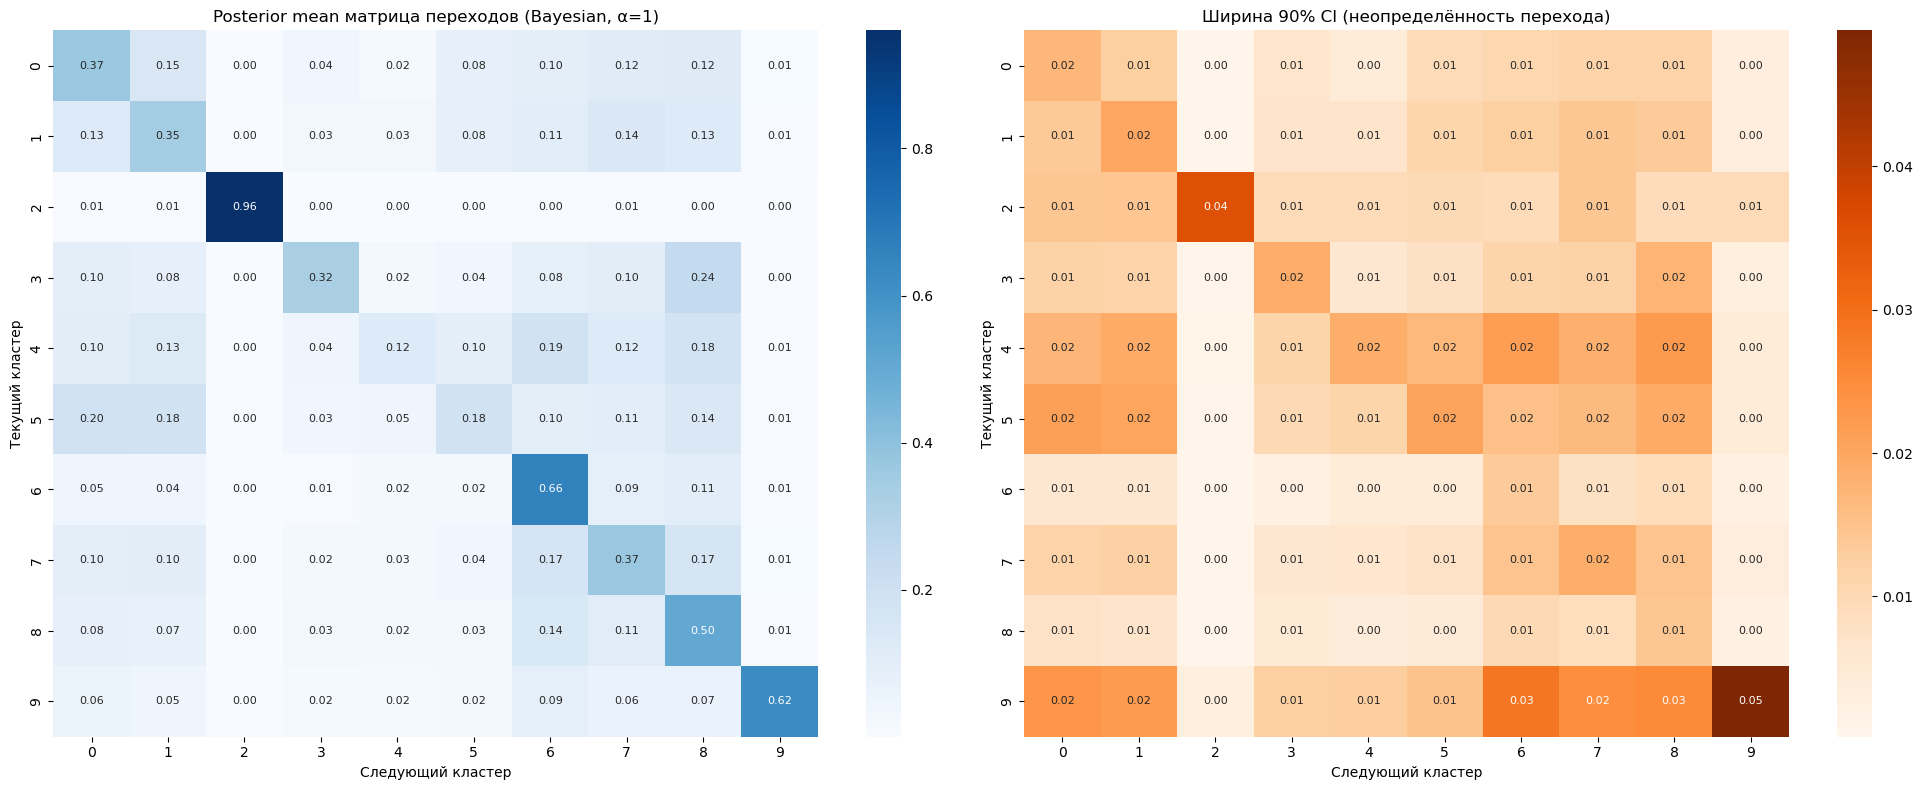

In [11]:
# Bayesian Dirichlet-Multinomial smoothing (α=1)
alpha_km = counts_km + 1

N_SAMPLES = 5000
posterior_km = {s: np.random.dirichlet(alpha_km.loc[s].values.astype(float), size=N_SAMPLES)
                for s in states}

P_bayes_km = pd.DataFrame(
    {s: alpha_km.loc[s].values / alpha_km.loc[s].values.sum() for s in states},
    index=states
).T

ci_low_km  = pd.DataFrame({s: np.percentile(posterior_km[s],  5, axis=0) for s in states}, index=states).T
ci_high_km = pd.DataFrame({s: np.percentile(posterior_km[s], 95, axis=0) for s in states}, index=states).T

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(P_bayes_km, annot=True, fmt='.2f', cmap='Blues',  ax=axes[0], annot_kws={'size': 8})
axes[0].set_title('Posterior mean матрица переходов (Bayesian, α=1)')
sns.heatmap(ci_high_km - ci_low_km, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1], annot_kws={'size': 8})
axes[1].set_title('Ширина 90% CI (неопределённость перехода)')
for ax in axes:
    ax.set_xlabel('Следующий кластер')
    ax.set_ylabel('Текущий кластер')
plt.tight_layout()
plt.show()

In [12]:
# Оценка Markov baseline на тесте
from sklearn.metrics import accuracy_score, log_loss

test_m = test_km.copy()
test_m['cluster_id']      = test_m['cluster_id'].astype(int)
test_m['cluster_id_next'] = test_m['cluster_id_next'].astype(int)

labels_sorted = sorted(states)
proba_bayes = np.vstack(
    [P_bayes_km.loc[row['cluster_id'], labels_sorted].values for _, row in test_m.iterrows()]
)
y_pred_markov = [labels_sorted[i] for i in np.argmax(proba_bayes, axis=1)]

acc_markov  = accuracy_score(test_m['cluster_id_next'], y_pred_markov)
loss_markov = log_loss(test_m['cluster_id_next'], proba_bayes, labels=labels_sorted)

print(f'Markov Bayesian — Accuracy: {acc_markov:.4f}  |  Log-loss: {loss_markov:.4f}')

Markov Bayesian — Accuracy: 0.5350  |  Log-loss: 1.4322


## 6b. Markov Downgrade baseline

Вместо предсказания *конкретного следующего кластера* суммируем вероятности переходов
во все кластеры с меньшим рангом — получаем P(downgrade) из матрицы переходов.

P(downgrade | cluster):
  cluster 7 (rank 0.0): 0.000
  cluster 2 (rank 1.0): 0.007
  cluster 3 (rank 2.0): 0.104
  cluster 9 (rank 3.0): 0.079
  cluster 6 (rank 4.0): 0.100
  cluster 0 (rank 5.0): 0.263
  cluster 8 (rank 6.0): 0.374
  cluster 1 (rank 7.0): 0.544
  cluster 5 (rank 8.0): 0.766
  cluster 4 (rank 9.0): 0.876

Markov Downgrade Baseline (threshold=0.5):
  Accuracy : 0.8374
  ROC-AUC  : 0.8605
  F1       : 0.5944
  Log-loss : 0.3658

Classification Report:
              precision    recall  f1-score   support

No downgrade       0.88      0.92      0.90     11867
   Downgrade       0.66      0.54      0.59      3377

    accuracy                           0.84     15244
   macro avg       0.77      0.73      0.75     15244
weighted avg       0.83      0.84      0.83     15244



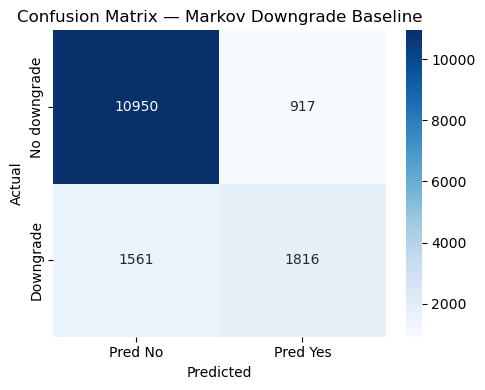

In [13]:
# --- Markov Downgrade Baseline ---
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    log_loss, classification_report, confusion_matrix
)

# Ранги кластеров (берём из train, они должны быть consistent)
rank_map = (
    train_km[['cluster_id', 'cluster_rank']]
    .drop_duplicates()
    .set_index('cluster_id')['cluster_rank']
    .to_dict()
)

# P(downgrade | current_cluster) = сумма вероятностей перехода в кластеры с меньшим рангом
downgrade_proba_map = {}
for cluster in states:
    rank_cur = rank_map.get(cluster, 0)
    p_down = sum(
        P_bayes_km.loc[cluster, c]
        for c in states
        if rank_map.get(c, 0) < rank_cur
    )
    downgrade_proba_map[cluster] = p_down

print('P(downgrade | cluster):')
for k, v in sorted(downgrade_proba_map.items(), key=lambda x: rank_map.get(x[0], 0)):
    print(f'  cluster {k} (rank {rank_map.get(k,"?"):.1f}): {v:.3f}')

# Применяем к тесту
test_mk = test_km.copy()
test_mk['cluster_id'] = test_mk['cluster_id'].astype(int)
test_mk['markov_down_proba'] = test_mk['cluster_id'].map(downgrade_proba_map)

y_true_mk = test_mk['downgrade'].values
y_prob_mk = test_mk['markov_down_proba'].values

# Порог 0.5
y_pred_mk = (y_prob_mk >= 0.5).astype(int)

# --- Метрики ---
acc_mk   = accuracy_score(y_true_mk, y_pred_mk)
auc_mk   = roc_auc_score(y_true_mk, y_prob_mk)
f1_mk    = f1_score(y_true_mk, y_pred_mk)
ll_mk    = log_loss(y_true_mk, y_prob_mk)

print(f'\nMarkov Downgrade Baseline (threshold=0.5):')
print(f'  Accuracy : {acc_mk:.4f}')
print(f'  ROC-AUC  : {auc_mk:.4f}')
print(f'  F1       : {f1_mk:.4f}')
print(f'  Log-loss : {ll_mk:.4f}')

print('\nClassification Report:')
print(classification_report(y_true_mk, y_pred_mk, target_names=['No downgrade', 'Downgrade']))

# Confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm_mk = confusion_matrix(y_true_mk, y_pred_mk)
cm_mk_df = pd.DataFrame(cm_mk,
    index=['No downgrade', 'Downgrade'],
    columns=['Pred No', 'Pred Yes']
)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_mk_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix — Markov Downgrade Baseline')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## 7. Матрица признаков для бинарных классификаторов

In [13]:
# cluster_rank вместо OHE сегмента
BASE_FEATS_BIN = [
    'total_orders', 'delivered_ratio', 'items', 'most_freq_order_size',
    'cancel_ratio', 'return_ratio', 'revenue', 'margin', 'avg_order_value',
    'recency_days', 'days_since_first_purchase',
    'ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ',
    'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КОСМЕТИКА/ГИГИЕНА',
    'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ',
    'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'ТЕКСТИЛЬ, ТРИКОТАЖ',
    'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ',
    'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ',
    'CENTRAL', 'FAR EAST', 'NORTH', 'PRIVOLZIE',
    'SIBERIA', 'SOUTHERN', 'URAL',
    'delivery_pick point', 'delivery_курьерская',
    'delivery_самовывоз', 'payment_безналичная',
    'cluster_rank',
]

X_train_bin = train_km[BASE_FEATS_BIN].copy()
y_train_bin = train_km['downgrade'].copy()
X_test_bin  = test_km[BASE_FEATS_BIN].copy()
y_test_bin  = test_km['downgrade'].copy()

print('X_train_bin:', X_train_bin.shape, '| X_test_bin:', X_test_bin.shape)
print('Train downgrade rate:', y_train_bin.mean().round(3))
print('Test downgrade rate: ', y_test_bin.mean().round(3))

# --- CV-сплит по времени ---
# PredefinedSplit точнее TimeSeriesSplit(n_splits=2):
#   TimeSeriesSplit делит по позиции (на 3 равные части), игнорируя реальные границы кварталов.
#   PredefinedSplit явно задаёт: Q1→Q2 = train (-1), Q2→Q3 = val (0).
# Итог: 1 фолд, зеркалящий тест: обучаемся на прошлом, валидируемся на следующем квартале.
from sklearn.model_selection import PredefinedSplit

test_fold_arr = np.where(train_km['quarter'] == train_quarters[0], -1, 0)
tscv = PredefinedSplit(test_fold=test_fold_arr)

n_train_cv = (test_fold_arr == -1).sum()
n_val_cv   = (test_fold_arr ==  0).sum()
print(f'\nCV (PredefinedSplit): train={n_train_cv} ({train_quarters[0]}→next) | val={n_val_cv} ({train_quarters[1]}→next)')


X_train_bin: (63845, 36) | X_test_bin: (15244, 36)
Train downgrade rate: 0.296
Test downgrade rate:  0.222

CV (PredefinedSplit): train=35612 (2017Q1→next) | val=28233 (2017Q2→next)


In [14]:
# Preprocessing — тот же пайплайн что в segment overflows.ipynb
HEAVY_BIN    = ['items', 'revenue', 'margin', 'avg_order_value', 'most_freq_order_size']
STANDARD_BIN = ['delivered_ratio', 'cancel_ratio', 'return_ratio', 'recency_days']

for col in set(HEAVY_BIN + STANDARD_BIN):
    X_train_bin[col] = X_train_bin[col].astype(float)
    X_test_bin[col]  = X_test_bin[col].astype(float)

# margin shift (fit only on train)
margin_shift_bin = float(-X_train_bin['margin'].min() + 1.0)
X_train_bin['margin'] = X_train_bin['margin'] + margin_shift_bin
X_test_bin['margin']  = (X_test_bin['margin'] + margin_shift_bin).clip(lower=0.0)

# log1p heavy tail
for col in HEAVY_BIN:
    X_train_bin[col] = np.log1p(X_train_bin[col].clip(lower=0.0))
    X_test_bin[col]  = np.log1p(X_test_bin[col].clip(lower=0.0))

# RobustScaler
robust_sc_bin = RobustScaler()
X_train_bin[HEAVY_BIN] = robust_sc_bin.fit_transform(X_train_bin[HEAVY_BIN])
X_test_bin[HEAVY_BIN]  = robust_sc_bin.transform(X_test_bin[HEAVY_BIN])

# StandardScaler
std_sc_bin = StandardScaler()
X_train_bin[STANDARD_BIN] = std_sc_bin.fit_transform(X_train_bin[STANDARD_BIN])
X_test_bin[STANDARD_BIN]  = std_sc_bin.transform(X_test_bin[STANDARD_BIN])

# LightGBM и XGBoost не поддерживают спецсимволы в именах колонок
import re
from collections import Counter

def sanitize_col(name):
    cleaned = re.sub(r'[^\w]+', '_', str(name)).strip('_')
    return cleaned or 'feature'

def make_unique_feature_names(columns):
    counts = {}
    unique_names = []
    for col in columns:
        base = sanitize_col(col)
        idx = counts.get(base, 0)
        new_name = base if idx == 0 else f'{base}_{idx}'
        counts[base] = idx + 1
        unique_names.append(new_name)
    return unique_names

original_cols = X_train_bin.columns.tolist()
sanitized_base = [sanitize_col(c) for c in original_cols]
sanitized_cols = make_unique_feature_names(original_cols)

# Важно: назначаем имена по позиции, а не через rename(columns=dict),
# потому что после неудачного предыдущего запуска в DataFrame уже могут быть дубликаты.
X_train_bin.columns = sanitized_cols
X_test_bin.columns  = sanitized_cols

resolved_dups = {
    base: [name for name in sanitized_cols if name == base or name.startswith(f'{base}_')]
    for base, cnt in Counter(sanitized_base).items() if cnt > 1
}
if resolved_dups:
    print('Resolved sanitized duplicates:', resolved_dups)

assert X_train_bin.columns.is_unique, 'X_train_bin still has duplicate feature names'
assert X_test_bin.columns.is_unique, 'X_test_bin still has duplicate feature names'

print('X_train_bin:', X_train_bin.shape, '| NaNs:', X_train_bin.isna().sum().sum())
print('X_test_bin: ', X_test_bin.shape,  '| NaNs:', X_test_bin.isna().sum().sum())
print('Columns sanitized:', X_train_bin.columns.tolist())

X_train_bin: (63845, 36) | NaNs: 0
X_test_bin:  (15244, 36) | NaNs: 0
Columns sanitized: ['total_orders', 'delivered_ratio', 'items', 'most_freq_order_size', 'cancel_ratio', 'return_ratio', 'revenue', 'margin', 'avg_order_value', 'recency_days', 'days_since_first_purchase', 'ДЕТСКОЕ_ПИТАНИЕ', 'ЖЕНСКИЕ_ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ_КНИГИ_ДИСКИ', 'КОСМЕТИКА_ГИГИЕНА', 'КРУПНОГАБАРИТНЫЙ_ТОВАР', 'ОБУВЬ', 'ПОДГУЗНИКИ', 'СОПУТСТВУЮЩИЕ_ТОВАРЫ', 'ТЕКСТИЛЬ_ТРИКОТАЖ', 'ТЕХНИКА_И_ТОВАРЫ_ДЛЯ_ДОМА', 'ТОВАРЫ_ДЛЯ_ЖИВОТНЫХ', 'ТОВАРЫ_ДЛЯ_КОРМЛЕНИЯ', 'CENTRAL', 'FAR_EAST', 'NORTH', 'PRIVOLZIE', 'SIBERIA', 'SOUTHERN', 'URAL', 'delivery_pick_point', 'delivery_курьерская', 'delivery_самовывоз', 'payment_безналичная', 'cluster_rank']


## 8. Бинарные классификаторы

### Logistic regression

In [15]:
# --- Logistic Regression ---
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

logreg_bin = LogisticRegression(max_iter=4000, class_weight='balanced', random_state=RANDOM_STATE)
logreg_bin.fit(X_train_bin, y_train_bin)

y_pred_lr  = logreg_bin.predict(X_test_bin)
y_prob_lr  = logreg_bin.predict_proba(X_test_bin)[:, 1]

print('Logistic Regression')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_lr):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_lr):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_prob_lr):.4f}')
print(classification_report(y_test_bin, y_pred_lr, digits=3))

Logistic Regression
  Accuracy: 0.7444
  F1:       0.5940
  ROC-AUC:  0.8720
              precision    recall  f1-score   support

           0      0.942     0.716     0.814     11867
           1      0.458     0.844     0.594      3377

    accuracy                          0.744     15244
   macro avg      0.700     0.780     0.704     15244
weighted avg      0.835     0.744     0.765     15244



Optimal threshold LR: 0.6052
F1 (opt): 0.620  |  Recall: 0.656  |  ROC-AUC: 0.872


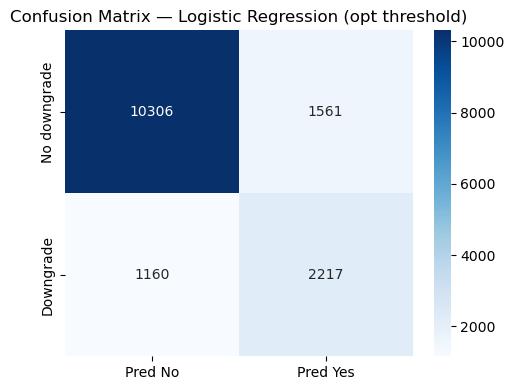

In [16]:
# Порог LR
from sklearn.metrics import precision_recall_curve, recall_score

prec_lr, rec_lr, thr_lr = precision_recall_curve(y_test_bin, y_prob_lr)
f1_lr_arr = 2 * (prec_lr * rec_lr) / (prec_lr + rec_lr + 1e-8)
best_thr_lr = thr_lr[f1_lr_arr[:-1].argmax()]
y_pred_lr_opt = (y_prob_lr >= best_thr_lr).astype(int)

print(f'Optimal threshold LR: {best_thr_lr:.4f}')
print(f'F1 (opt): {f1_score(y_test_bin, y_pred_lr_opt):.3f}  |  Recall: {recall_score(y_test_bin, y_pred_lr_opt):.3f}  |  ROC-AUC: {roc_auc_score(y_test_bin, y_prob_lr):.3f}')

cm = confusion_matrix(y_test_bin, y_pred_lr_opt)
cm_df = pd.DataFrame(cm, index=['No downgrade', 'Downgrade'], columns=['Pred No', 'Pred Yes'])
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (opt threshold)')
plt.tight_layout()
plt.show()

### Light GBM

In [36]:
# --- LightGBM: подбор гиперпараметров ---
from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV

assert X_train_bin.columns.is_unique, f'Duplicate train columns: {X_train_bin.columns[X_train_bin.columns.duplicated()].tolist()}'
assert X_test_bin.columns.is_unique, f'Duplicate test columns: {X_test_bin.columns[X_test_bin.columns.duplicated()].tolist()}'

lgbm_base = LGBMClassifier(
    objective='binary', class_weight='balanced',
    random_state=RANDOM_STATE, force_row_wise=True, verbose=-1
)

lgbm_param_dist = {
    'n_estimators':      [200, 300, 400, 500],
    'learning_rate':    [0.03, 0.05, 0.07, 0.1],
    'num_leaves':       [15, 31, 63],
    'max_depth':        [4, 5, 6, -1],
    'min_child_samples':[20, 30, 50, 80],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_lambda':       [0.0, 0.5, 1.0, 2.0],
}

lgbm_search = RandomizedSearchCV(
    lgbm_base, lgbm_param_dist, n_iter=15, cv=tscv,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train_bin, y_train_bin)

print(f'Best params: {lgbm_search.best_params_}')
print(f'Best CV AUC: {lgbm_search.best_score_:.4f}')

lgbm_bin = lgbm_search.best_estimator_
y_pred_lgbm = lgbm_bin.predict(X_test_bin)
y_prob_lgbm = lgbm_bin.predict_proba(X_test_bin)[:, 1]

print('LightGBM')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_lgbm):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_lgbm):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_prob_lgbm):.4f}')
print(classification_report(y_test_bin, y_pred_lgbm, digits=3))

Best params: {'subsample': 0.8, 'reg_lambda': 0.0, 'num_leaves': 15, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV AUC: 0.8461
LightGBM
  Accuracy: 0.7468
  F1:       0.6031
  ROC-AUC:  0.8819
              precision    recall  f1-score   support

           0      0.950     0.712     0.814     11867
           1      0.462     0.869     0.603      3377

    accuracy                          0.747     15244
   macro avg      0.706     0.790     0.709     15244
weighted avg      0.842     0.747     0.767     15244



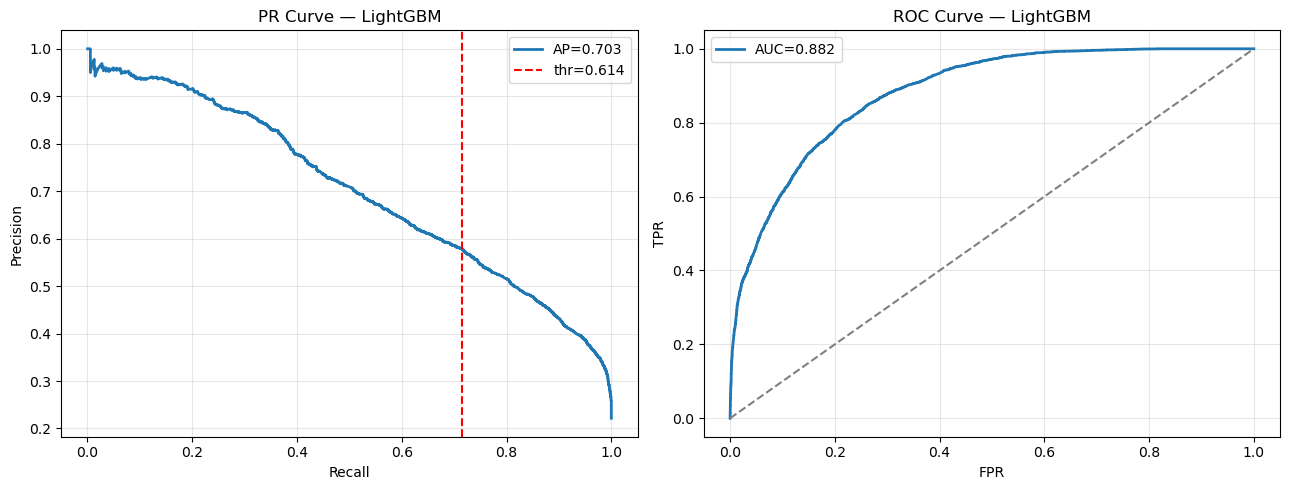

LightGBM opt thr=0.6139  F1=0.640  Recall=0.715  AUC=0.882


In [37]:
# Порог LightGBM + PR/ROC curves
from sklearn.metrics import precision_recall_curve, roc_curve, average_precision_score

prec_lgbm, rec_lgbm, thr_lgbm = precision_recall_curve(y_test_bin, y_prob_lgbm)
f1_lgbm_arr = 2 * (prec_lgbm * rec_lgbm) / (prec_lgbm + rec_lgbm + 1e-8)
best_thr_lgbm = thr_lgbm[f1_lgbm_arr[:-1].argmax()]
y_pred_lgbm_opt = (y_prob_lgbm >= best_thr_lgbm).astype(int)

fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test_bin, y_prob_lgbm)
ap_lgbm = average_precision_score(y_test_bin, y_prob_lgbm)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_lgbm[:-1], prec_lgbm[:-1], lw=2, label=f'AP={ap_lgbm:.3f}')
best_idx = f1_lgbm_arr[:-1].argmax()
axes[0].axvline(rec_lgbm[best_idx], color='red', linestyle='--', label=f'thr={best_thr_lgbm:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR Curve — LightGBM')
axes[0].legend(); axes[0].grid(alpha=0.3)

auc_lgbm = roc_auc_score(y_test_bin, y_prob_lgbm)
axes[1].plot(fpr_lgbm, tpr_lgbm, lw=2, label=f'AUC={auc_lgbm:.3f}')
axes[1].plot([0,1],[0,1], '--', color='gray')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve — LightGBM')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'LightGBM opt thr={best_thr_lgbm:.4f}  F1={f1_score(y_test_bin, y_pred_lgbm_opt):.3f}  Recall={recall_score(y_test_bin, y_pred_lgbm_opt):.3f}  AUC={auc_lgbm:.3f}')

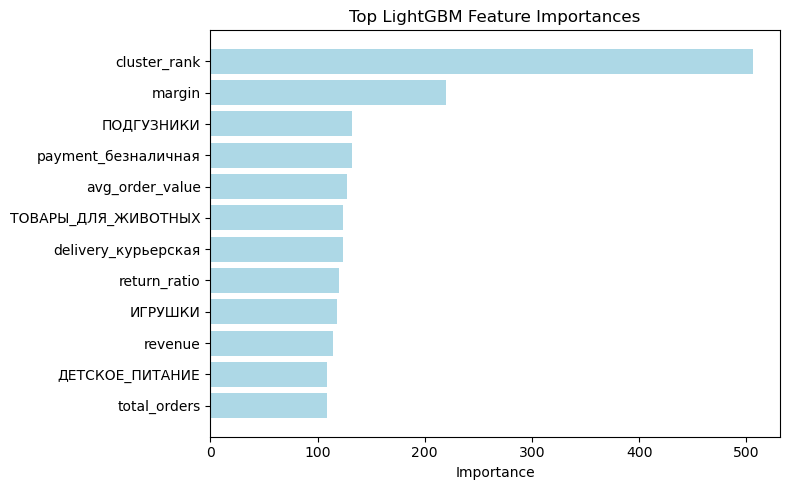

In [38]:
# LightGBM feature importance
fi_lgbm = pd.DataFrame({'feature': X_train_bin.columns,
                         'importance': lgbm_bin.feature_importances_}).sort_values('importance', ascending=False)
top12 = fi_lgbm.head(12).sort_values('importance')
plt.figure(figsize=(8, 5))
plt.barh(top12['feature'], top12['importance'], color='lightblue')
plt.xlabel('Importance')
plt.title('Top LightGBM Feature Importances')
plt.tight_layout()
plt.show()

### Random Forest

In [20]:
# --- Random Forest ---
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=900, max_depth=10, min_samples_leaf=20,
    max_features=0.7, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_model.fit(X_train_bin, y_train_bin)

y_pred_rf  = rf_model.predict(X_test_bin)
y_proba_rf = rf_model.predict_proba(X_test_bin)[:, 1]

print('Random Forest')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_rf):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_rf):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_rf):.4f}')
print(classification_report(y_test_bin, y_pred_rf, digits=3))

Random Forest
  Accuracy: 0.7666
  F1:       0.6146
  ROC-AUC:  0.8822
              precision    recall  f1-score   support

           0      0.942     0.746     0.833     11867
           1      0.485     0.840     0.615      3377

    accuracy                          0.767     15244
   macro avg      0.714     0.793     0.724     15244
weighted avg      0.841     0.767     0.784     15244



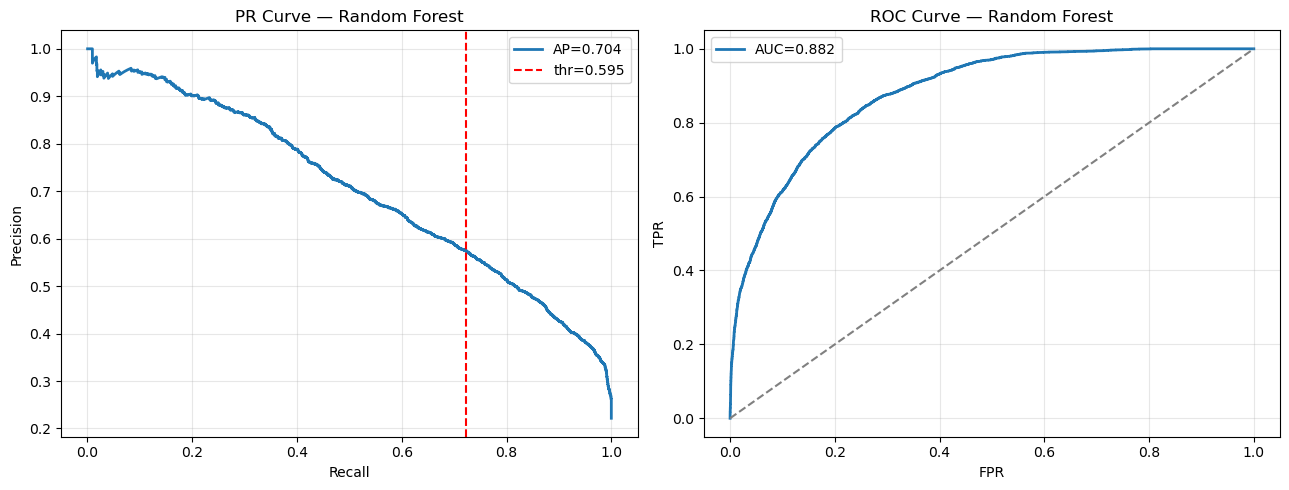

RF opt thr=0.5946  F1=0.641  Recall=0.722  AUC=0.882


In [21]:
# Порог RF + PR/ROC
prec_rf, rec_rf, thr_rf_arr = precision_recall_curve(y_test_bin, y_proba_rf)
f1_rf_arr = 2 * (prec_rf * rec_rf) / (prec_rf + rec_rf + 1e-8)
best_thr_rf = thr_rf_arr[f1_rf_arr[:-1].argmax()]
y_pred_rf_opt = (y_proba_rf >= best_thr_rf).astype(int)

fpr_rf, tpr_rf, _ = roc_curve(y_test_bin, y_proba_rf)
ap_rf  = average_precision_score(y_test_bin, y_proba_rf)
auc_rf = roc_auc_score(y_test_bin, y_proba_rf)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec_rf[:-1], prec_rf[:-1], lw=2, label=f'AP={ap_rf:.3f}')
axes[0].axvline(rec_rf[f1_rf_arr[:-1].argmax()], color='red', linestyle='--', label=f'thr={best_thr_rf:.3f}')
axes[0].set(xlabel='Recall', ylabel='Precision', title='PR Curve — Random Forest')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(fpr_rf, tpr_rf, lw=2, label=f'AUC={auc_rf:.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set(xlabel='FPR', ylabel='TPR', title='ROC Curve — Random Forest')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'RF opt thr={best_thr_rf:.4f}  F1={f1_score(y_test_bin, y_pred_rf_opt):.3f}  Recall={recall_score(y_test_bin, y_pred_rf_opt):.3f}  AUC={auc_rf:.3f}')

### XGBoost

In [22]:
# --- XGBoost: подбор гиперпараметров ---
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

scale_pos_weight = (y_train_bin == 0).sum() / (y_train_bin == 1).sum()

xgb_base = XGBClassifier(
    objective='binary:logistic', eval_metric='auc',
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0
)

xgb_param_dist = {
    'n_estimators':      [200, 300, 400, 500],
    'max_depth':         [3, 4, 5, 6],
    'learning_rate':     [0.03, 0.05, 0.07, 0.1],
    'min_child_weight':  [1, 3, 5],
    'subsample':         [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':  [0.7, 0.8, 0.9, 1.0],
    'gamma':             [0.0, 0.1, 0.3],
    'reg_lambda':        [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    xgb_base, xgb_param_dist, n_iter=15, cv=tscv,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train_bin, y_train_bin)

print(f'Best params: {xgb_search.best_params_}')
print(f'Best CV AUC: {xgb_search.best_score_:.4f}')

xgb_model = xgb_search.best_estimator_
y_pred_xgb = xgb_model.predict(X_test_bin)
y_proba_xgb = xgb_model.predict_proba(X_test_bin)[:, 1]

print('XGBoost')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_xgb):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_xgb):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_xgb):.4f}')
print(classification_report(y_test_bin, y_pred_xgb, digits=3))

Best params: {'subsample': 0.9, 'reg_lambda': 2.0, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV AUC: 0.8464
XGBoost
  Accuracy: 0.7515
  F1:       0.6062
  ROC-AUC:  0.8831
              precision    recall  f1-score   support

           0      0.949     0.720     0.818     11867
           1      0.467     0.863     0.606      3377

    accuracy                          0.752     15244
   macro avg      0.708     0.792     0.712     15244
weighted avg      0.842     0.752     0.771     15244



In [23]:
# Порог XGBoost
prec_xgb, rec_xgb, thr_xgb_arr = precision_recall_curve(y_test_bin, y_proba_xgb)
f1_xgb_arr = 2 * (prec_xgb * rec_xgb) / (prec_xgb + rec_xgb + 1e-8)
best_thr_xgb = thr_xgb_arr[f1_xgb_arr[:-1].argmax()]
y_pred_xgb_opt = (y_proba_xgb >= best_thr_xgb).astype(int)

auc_xgb = roc_auc_score(y_test_bin, y_proba_xgb)
print(f'XGBoost opt thr={best_thr_xgb:.4f}  F1={f1_score(y_test_bin, y_pred_xgb_opt):.3f}  Recall={recall_score(y_test_bin, y_pred_xgb_opt):.3f}  AUC={auc_xgb:.3f}')

XGBoost opt thr=0.6110  F1=0.640  Recall=0.710  AUC=0.883


### SVM

In [24]:
# --- SVM ---
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale',
                probability=True, class_weight='balanced', random_state=RANDOM_STATE))
])
svm_model.fit(X_train_bin, y_train_bin)

y_proba_svm = svm_model.predict_proba(X_test_bin)[:, 1]
y_pred_svm  = (y_proba_svm >= 0.5).astype(int)

print('SVM')
print(f'  Accuracy: {accuracy_score(y_test_bin, y_pred_svm):.4f}')
print(f'  F1:       {f1_score(y_test_bin, y_pred_svm):.4f}')
print(f'  ROC-AUC:  {roc_auc_score(y_test_bin, y_proba_svm):.4f}')

SVM
  Accuracy: 0.7945
  F1:       0.6075
  ROC-AUC:  0.8555


In [25]:
# Порог SVM
prec_svm, rec_svm, thr_svm_arr = precision_recall_curve(y_test_bin, y_proba_svm)
f1_svm_arr = 2 * (prec_svm * rec_svm) / (prec_svm + rec_svm + 1e-8)
best_thr_svm = thr_svm_arr[f1_svm_arr[:-1].argmax()]
y_pred_svm_opt = (y_proba_svm >= best_thr_svm).astype(int)

auc_svm = roc_auc_score(y_test_bin, y_proba_svm)
print(f'SVM opt thr={best_thr_svm:.4f}  F1={f1_score(y_test_bin, y_pred_svm_opt):.3f}  Recall={recall_score(y_test_bin, y_pred_svm_opt):.3f}  AUC={auc_svm:.3f}')

SVM opt thr=0.3987  F1=0.610  Recall=0.795  AUC=0.856


### MLP

In [26]:
# --- MLP ---
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV

sample_weight_bin = compute_sample_weight(class_weight='balanced', y=y_train_bin)

mlp_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(
        early_stopping=True, validation_fraction=0.1,
        n_iter_no_change=15, random_state=RANDOM_STATE, max_iter=400
    ))
])

param_dist = {
    'model__hidden_layer_sizes': [(128, 64), (256, 128, 64), (128, 64, 32), (256, 128)],
    'model__alpha':              [1e-5, 1e-4, 1e-3, 1e-2],
    'model__learning_rate_init': [1e-4, 5e-4, 1e-3],
    'model__activation':         ['relu', 'tanh'],
    'model__batch_size':         [128, 256, 512],
}

search = RandomizedSearchCV(
    mlp_pipeline, param_dist, n_iter=20, cv=tscv,
    scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
search.fit(X_train_bin, y_train_bin, model__sample_weight=sample_weight_bin)

print(f'Best params: {search.best_params_}')
print(f'Best CV AUC: {search.best_score_:.4f}')

mlp_bin      = search.best_estimator_
y_proba_mlp  = mlp_bin.predict_proba(X_test_bin)[:, 1]

prec_mlp, rec_mlp, thr_mlp_arr = precision_recall_curve(y_test_bin, y_proba_mlp)
f1_mlp_arr = 2 * (prec_mlp * rec_mlp) / (prec_mlp + rec_mlp + 1e-8)
best_threshold = thr_mlp_arr[f1_mlp_arr[:-1].argmax()]
y_pred_mlp   = (y_proba_mlp >= best_threshold).astype(int)

auc_mlp = roc_auc_score(y_test_bin, y_proba_mlp)
print(f'MLP opt thr={best_threshold:.4f}  F1={f1_score(y_test_bin, y_pred_mlp):.3f}  Recall={recall_score(y_test_bin, y_pred_mlp):.3f}  AUC={auc_mlp:.3f}')

Best params: {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (128, 64, 32), 'model__batch_size': 128, 'model__alpha': 0.001, 'model__activation': 'tanh'}
Best CV AUC: 0.8409
MLP opt thr=0.6712  F1=0.622  Recall=0.652  AUC=0.875


## 9. Итоговое сравнение моделей

In [27]:
from sklearn.metrics import recall_score, precision_score

models_info = [
    ('Logistic Regression', y_prob_lr,    y_pred_lr_opt,    best_thr_lr),
    ('LightGBM',            y_prob_lgbm,  y_pred_lgbm_opt,  best_thr_lgbm),
    ('Random Forest',       y_proba_rf,   y_pred_rf_opt,    best_thr_rf),
    ('XGBoost',             y_proba_xgb,  y_pred_xgb_opt,   best_thr_xgb),
    ('SVM',                 y_proba_svm,  y_pred_svm_opt,   best_thr_svm),
    ('MLP',                 y_proba_mlp,  y_pred_mlp,       best_threshold),
]

rows = []
for name, y_prob, y_pred, thr in models_info:
    rows.append({
        'Model':     name,
        'Threshold': round(thr, 3),
        'ROC AUC':   round(roc_auc_score(y_test_bin, y_prob), 3),
        'F1':        round(f1_score(y_test_bin, y_pred), 3),
        'Recall':    round(recall_score(y_test_bin, y_pred), 3),
        'Precision': round(precision_score(y_test_bin, y_pred), 3),
    })

comparison_km = pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False)
print('=== K-means: все модели с оптимальным порогом ===')
comparison_km

=== K-means: все модели с оптимальным порогом ===


,Threshold,ROC AUC,F1,Recall,Precision
Model,,,,,
Random Forest,0.595,0.882,0.641,0.722,0.576
LightGBM,0.614,0.882,0.640,0.715,0.578
XGBoost,0.611,0.883,0.640,0.710,0.583
MLP,0.671,0.875,0.622,0.652,0.594
Logistic Regression,0.605,0.872,0.620,0.656,0.587
SVM,0.399,0.856,0.610,0.795,0.495


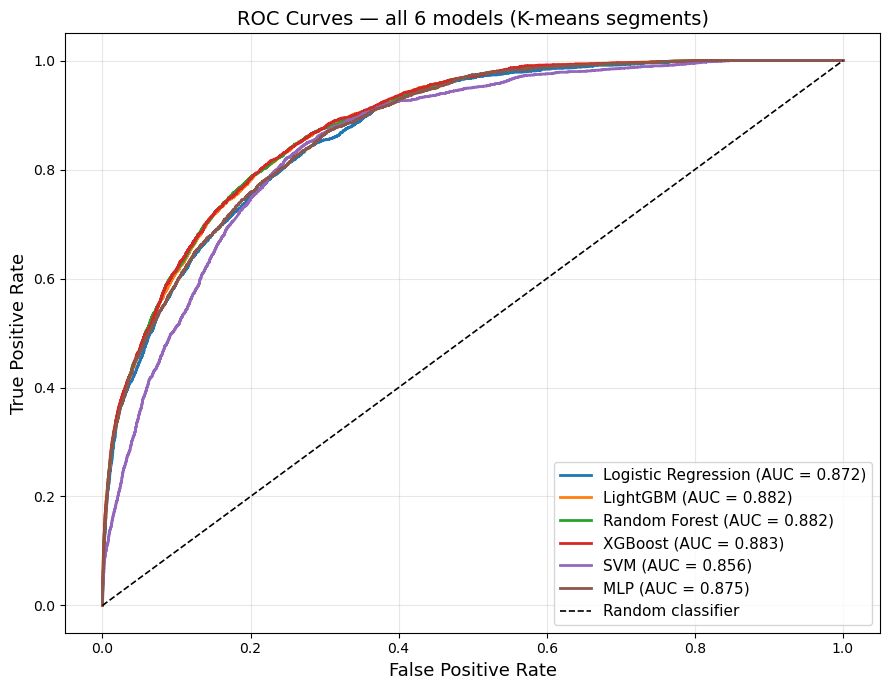

In [28]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for (name, y_prob, _, _), color in zip(models_info, colors):
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title("ROC Curves — all 6 models (K-means segments)", fontsize=14)
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Сравнение K-means vs RFM

In [29]:
# Cohen's Kappa: насколько совпадают метки downgrade (K-means vs RFM)
# Для сравнения нужен df_rfm из segment overflows.ipynb
# Воспроизводим RFM-логику здесь

# --- RFM functions (копия из segment overflows.ipynb) ---
SEGMENT_RANK = {'Champions':5, 'Loyal':4, 'Promising':3, 'Regular':2, 'At Risk':1, 'Lost':0}

def score_asc(x, bins):
    if x <= bins[0]: return 5
    elif x <= bins[1]: return 4
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 2
    else: return 1

def score_desc(x, bins):
    if x <= bins[0]: return 1
    elif x <= bins[1]: return 2
    elif x <= bins[2]: return 3
    elif x <= bins[3]: return 4
    else: return 5

def score_frequency(x):
    if x <= 1: return 1
    elif x == 2: return 2
    elif x <= 4: return 3
    elif x <= 8: return 4
    else: return 5

def add_rfm_and_segment(df_in, bins_df=None):
    out = df_in.copy()
    out['recency_days'] = out['recency_days'].fillna(out['recency_days'].max())
    out['total_orders'] = out['total_orders'].fillna(0)
    out['margin']       = out['margin'].fillna(0)
    base = out if bins_df is None else bins_df
    q = [0.2, 0.4, 0.6, 0.8]
    r_bins = base['recency_days'].quantile(q).values
    m_bins = base['margin'].quantile(q).values
    out['R_score'] = out['recency_days'].apply(lambda x: score_asc(x, r_bins))
    out['F_score'] = out['total_orders'].apply(score_frequency)
    out['M_score'] = out['margin'].apply(lambda x: score_desc(x, m_bins))
    out['RFM_sum'] = out['R_score'] + out['F_score'] + out['M_score']
    conditions = [
        (out['R_score'] >= 4) & (out['F_score'] >= 3) & (out['M_score'] >= 3),
        (out['R_score'] >= 3) & (out['F_score'] >= 3),
        (out['R_score'] >= 4) & (out['F_score'] <= 2),
        (out['R_score'] <= 2) & ((out['F_score'] >= 3) | (out['M_score'] >= 3)),
        (out['R_score'] == 1) & (out['F_score'] <= 2) & (out['M_score'] <= 2),
    ]
    choices = ['Champions', 'Loyal', 'Promising', 'At Risk', 'Lost']
    out['segment'] = np.select(conditions, choices, default='Regular')
    return out

# Загружаем df ещё раз (без PeriodIndex чтобы не ломать bins_base)
df_raw = pd.read_csv('data/client_pivot_quarter.csv')
bins_base = df_raw[df_raw['quarter'] != '2017Q4'].copy()
df_rfm = add_rfm_and_segment(df_raw, bins_df=bins_base)
df_rfm['quarter'] = pd.PeriodIndex(df_rfm['quarter'], freq='Q')

# Строим RFM переходы
df_rfm = df_rfm.sort_values(['Телефон_new', 'quarter'])
df_rfm['segment_next'] = df_rfm.groupby('Телефон_new')['segment'].shift(-1)
df_rfm['rank_t']    = df_rfm['segment'].map(SEGMENT_RANK)
df_rfm['rank_next'] = df_rfm['segment_next'].map(SEGMENT_RANK)
df_rfm['downgrade_rfm'] = (df_rfm['rank_next'] < df_rfm['rank_t']).astype(int)

# Тест: Q3→Q4 (quarter == 2017Q3)
test_rfm = df_rfm[
    (df_rfm['quarter'] == '2017Q3') & df_rfm['segment_next'].notna()
].copy()

print('test_rfm:', test_rfm.shape)
print('RFM downgrade rate (test):', test_rfm['downgrade_rfm'].mean().round(3))

test_rfm: (15244, 46)
RFM downgrade rate (test): 0.847


In [30]:
from sklearn.metrics import cohen_kappa_score

# Совмещаем по Телефон_new на тест-периоде
compare_df = test_km[['Телефон_new', 'downgrade']].rename(columns={'downgrade': 'downgrade_km'}).merge(
    test_rfm[['Телефон_new', 'downgrade_rfm']],
    on='Телефон_new', how='inner'
)

print(f'Matched clients: {len(compare_df)}')
print(f'K-means downgrade rate:  {compare_df["downgrade_km"].mean():.3f}')
print(f'RFM downgrade rate:      {compare_df["downgrade_rfm"].mean():.3f}')

kappa = cohen_kappa_score(compare_df['downgrade_km'], compare_df['downgrade_rfm'])
print(f'\nCohen Kappa (K-means vs RFM downgrade labels): {kappa:.4f}')

ct = pd.crosstab(compare_df['downgrade_km'], compare_df['downgrade_rfm'],
                  rownames=['K-means'], colnames=['RFM'])
print('\nCross-tabulation:')
print(ct)

Matched clients: 15244
K-means downgrade rate:  0.222
RFM downgrade rate:      0.847

Cohen Kappa (K-means vs RFM downgrade labels): -0.0134

Cross-tabulation:
RFM         0      1
K-means             
0        1747  10120
1         588   2789


In [31]:
# Сравнение ROC-AUC двух подходов
# Метрики RFM взяты из overflows RFM new.ipynb (Random Forest, opt threshold=0.308)

comparison_final = pd.DataFrame({
    'Метод':       ['K-means (этот ноутбук)', 'RFM (overflows RFM new.ipynb)'],
    'Best model':  ['LightGBM', 'Random Forest'],
    'ROC-AUC':     [round(auc_lgbm, 3), 0.758],
    'F1 (opt thr)': [round(f1_score(y_test_bin, y_pred_lgbm_opt), 3), 0.715],
    'Recall':      [round(recall_score(y_test_bin, y_pred_lgbm_opt), 3), 0.942],
    'Precision':   [round(precision_score(y_test_bin, y_pred_lgbm_opt), 3), 0.576],
    'Test size':   [len(y_test_bin), 15244],
    'Downgrade rate (test)': [round(y_test_bin.mean(), 3), 0.847],
})
print(comparison_final.to_string(index=False))

                        Метод    Best model  ROC-AUC  F1 (opt thr)  Recall  Precision  Test size  Downgrade rate (test)
       K-means (этот ноутбук)      LightGBM    0.882         0.640   0.715      0.578      15244                  0.222
RFM (overflows RFM new.ipynb) Random Forest    0.758         0.715   0.942      0.576      15244                  0.847


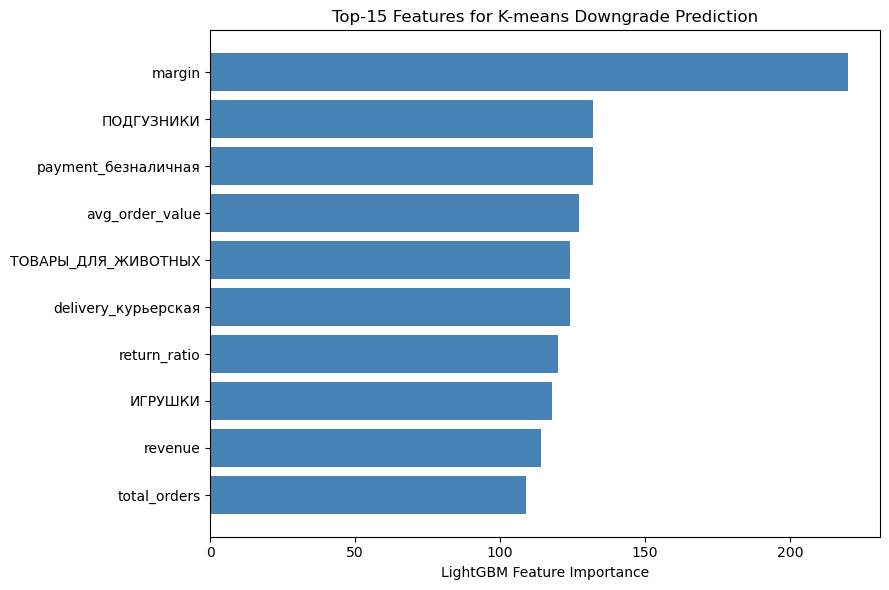


Позиция cluster_rank в feature importance:
         feature  importance
35  cluster_rank         506


In [32]:
# Feature importance: K-means vs RFM (топ-10)
# Для RFM берём из segment overflows fi_lgbm (нет здесь),
# поэтому показываем только K-means feature importance

fi_km_plot = fi_lgbm[1:11].sort_values('importance')

plt.figure(figsize=(9, 6))
plt.barh(fi_km_plot['feature'], fi_km_plot['importance'], color='steelblue')
plt.xlabel('LightGBM Feature Importance')
plt.title('Top-15 Features for K-means Downgrade Prediction')
plt.tight_layout()
plt.show()

print('\nПозиция cluster_rank в feature importance:')
print(fi_lgbm[fi_lgbm['feature'] == 'cluster_rank'])

In [84]:
print('=== ИТОГ ===')
print(f'Cohen Kappa (K-means vs RFM downgrade): {kappa:.4f}')
print()
print('Интерпретация:')
if kappa < 0.2:
    print('  Очень слабое согласие — K-means и RFM дают принципиально разные сигналы о downgrade.')
elif kappa < 0.4:
    print('  Слабое согласие — методы частично расходятся в определении at-risk клиентов.')
elif kappa < 0.6:
    print('  Умеренное согласие — методы похожи, но K-means улавливает дополнительные паттерны.')
elif kappa < 0.8:
    print('  Хорошее согласие — оба метода идентифицируют схожий набор at-risk клиентов.')
else:
    print('  Отличное согласие — K-means и RFM практически эквивалентны по сигналу о downgrade.')
print()
print(comparison_km.to_string())

=== ИТОГ ===
Cohen Kappa (K-means vs RFM downgrade): -0.0134

Интерпретация:
  Очень слабое согласие — K-means и RFM дают принципиально разные сигналы о downgrade.

                     Threshold  ROC AUC     F1  Recall  Precision
Model                                                            
Random Forest            0.595    0.882  0.641   0.722      0.576
LightGBM                 0.614    0.882  0.640   0.715      0.578
XGBoost                  0.611    0.883  0.640   0.710      0.583
MLP                      0.671    0.875  0.622   0.652      0.594
Logistic Regression      0.605    0.872  0.620   0.656      0.587
SVM                      0.399    0.856  0.610   0.795      0.495


# Survival Analysis

In [38]:
import pandas as pd
import numpy as np

surv_base = df_km[[
    "Телефон_new", "quarter", "cluster_id", "cluster_rank", "cluster_rank_next",
    "revenue", "margin", "avg_order_value",
    "recency_days", "total_orders",
    "cancel_ratio", "return_ratio", "delivered_ratio"
]].copy()

quarter_values = sorted(surv_base["quarter"].dropna().astype(str).unique())
quarter_order = {q: i + 1 for i, q in enumerate(quarter_values)}
surv_base["q_num"] = surv_base["quarter"].astype(str).map(quarter_order)

surv_base["rank_t"] = pd.to_numeric(surv_base["cluster_rank"], errors="coerce")
surv_base["rank_next"] = pd.to_numeric(surv_base["cluster_rank_next"], errors="coerce")

# downgrade = 1, если ранг кластера снизился (NaN rank_next = правая цензура)
surv_base["downgrade"] = (
    (surv_base["rank_next"] < surv_base["rank_t"]) &
    surv_base["rank_next"].notna()
).astype(int)

first_dg = (
    surv_base[surv_base["downgrade"] == 1]
    .groupby("Телефон_new")["q_num"].min().rename("event_q")
)
first_q = surv_base.groupby("Телефон_new")["q_num"].min().rename("first_q")
last_q = surv_base.groupby("Телефон_new")["q_num"].max().rename("last_q")

survival = pd.concat([first_q, last_q], axis=1).join(first_dg)
survival["event"] = survival["event_q"].notna().astype(int)
survival["duration"] = np.where(
    survival["event"] == 1,
    survival["event_q"] - survival["first_q"] + 1,
    survival["last_q"] - survival["first_q"] + 1,
)
survival = survival[survival["duration"] > 0].reset_index()

print(f"Клиентов в survival panel: {len(survival)}")
print("Event (downgrade):")
print(survival["event"].value_counts())
print("Длительность наблюдения (кварталов):")
print(survival["duration"].value_counts().sort_index())


Клиентов в survival panel: 288943
Event (downgrade):
event
0    267593
1     21350
Name: count, dtype: int64
Длительность наблюдения (кварталов):
duration
1.0    247787
2.0     24836
3.0     11990
4.0      4330
Name: count, dtype: int64


In [39]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("lifelines") is None:
    print("Installing lifelines...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lifelines", "--quiet"])
else:
    print("lifelines is already installed.")


lifelines is already installed.


### Kaplan-Meier

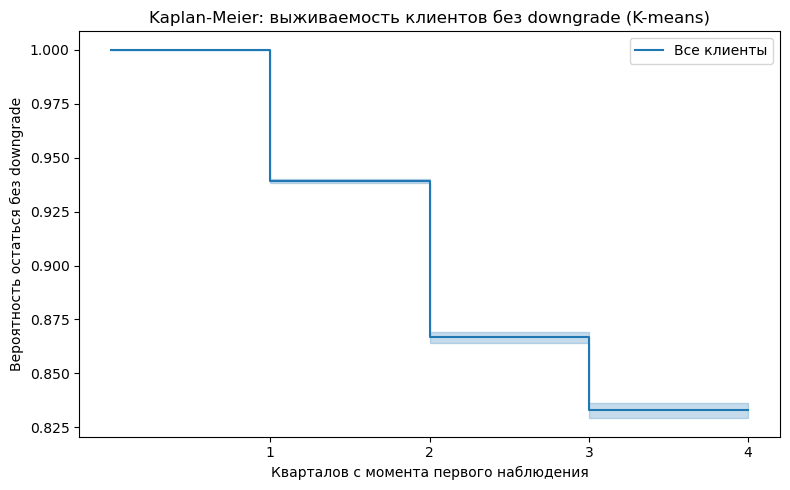

Медианное время до downgrade (кварталов): inf
Кривая выживаемости:
          Все клиенты
timeline             
0.0             1.000
1.0             0.939
2.0             0.867
3.0             0.833
4.0             0.833


In [40]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
kmf.fit(
    survival["duration"],
    event_observed=survival["event"],
    label="Все клиенты",
)

ax = kmf.plot_survival_function(ci_show=True, figsize=(8, 5))
ax.set_xlabel("Кварталов с момента первого наблюдения")
ax.set_ylabel("Вероятность остаться без downgrade")
ax.set_title("Kaplan-Meier: выживаемость клиентов без downgrade (K-means)")
ax.set_xticks(sorted(survival["duration"].unique()))
plt.tight_layout()
plt.show()

print("Медианное время до downgrade (кварталов):", kmf.median_survival_time_)
print("Кривая выживаемости:")
print(kmf.survival_function_.round(3))


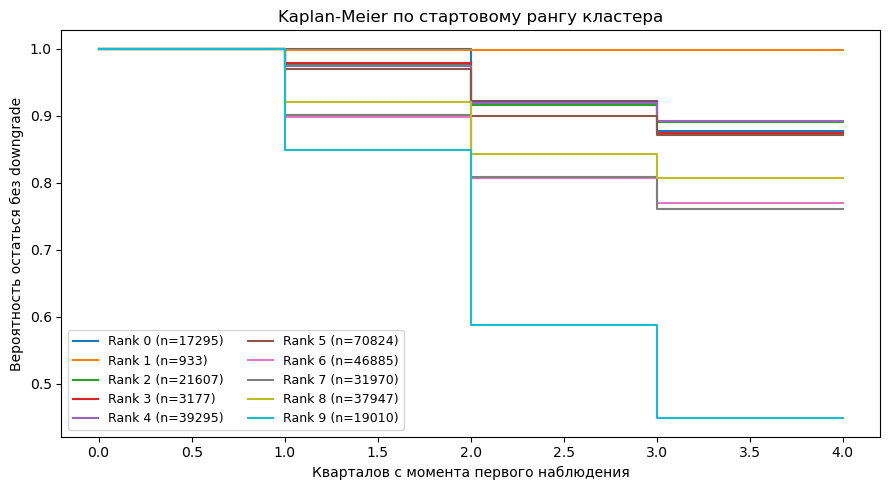

In [41]:
# Стратификация по стартовому рангу кластера клиента
first_rank = (
    surv_base.sort_values("q_num")
    .groupby("Телефон_new")["rank_t"].first()
    .rename("first_cluster_rank")
)
survival_seg = survival.set_index("Телефон_new").join(first_rank).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for rank in sorted(survival_seg["first_cluster_rank"].dropna().unique()):
    mask = survival_seg["first_cluster_rank"] == rank
    if mask.sum() < 20:
        continue
    kmf_rank = KaplanMeierFitter()
    kmf_rank.fit(
        survival_seg.loc[mask, "duration"],
        event_observed=survival_seg.loc[mask, "event"],
        label=f"Rank {int(rank)} (n={mask.sum()})",
    )
    kmf_rank.plot_survival_function(ax=ax, ci_show=False)

ax.set_xlabel("Кварталов с момента первого наблюдения")
ax.set_ylabel("Вероятность остаться без downgrade")
ax.set_title("Kaplan-Meier по стартовому рангу кластера")
ax.legend(fontsize=9, loc="lower left", ncol=2)
plt.tight_layout()
plt.show()


### Интерпретация Kaplan-Meier

Кривая выживаемости показывает, какая доля клиентов еще не пережила downgrade
к каждому квартальному порогу. В K-means-варианте stratification строится не по RFM-сегменту,
а по стартовому `cluster_rank` клиента.

Интерпретация кривых по группам:
- Чем круче падение кривой, тем быстрее клиенты данного ранга кластера деградируют.
- Плато означает правую цензуру: часть клиентов не переживает downgrade за весь период наблюдения.
- Сравнение кривых низких и высоких `cluster_rank` показывает, насколько стартовая позиция клиента
  связана с будущей устойчивостью.


### Cox Proportional Hazards

In [42]:
# Признаки клиента берем из его ПЕРВОГО наблюдаемого квартала
feature_cols = [
    "revenue", "margin", "avg_order_value",
    "recency_days", "total_orders",
    "cancel_ratio", "return_ratio", "delivered_ratio",
]

first_q_features = (
    surv_base.sort_values("q_num")
    .groupby("Телефон_new")
    .first()
    .reset_index()
)

cox_df = (
    survival.set_index("Телефон_new")[["duration", "event"]]
    .join(first_q_features.set_index("Телефон_new")[feature_cols])
    .dropna()
    .reset_index(drop=True)
)

print(f"cox_df shape: {cox_df.shape}")
print(f"Event rate: {cox_df['event'].mean():.3f}")
cox_df.describe().round(2)


cox_df shape: (288943, 10)
Event rate: 0.074


,duration,event,revenue,margin,avg_order_value,recency_days,total_orders,cancel_ratio,return_ratio,delivered_ratio
count,288943.00,288943.00,288943.00,288943.00,288943.00,288943.00,288943.00,288943.00,288943.00,288943.00
mean,1.21,0.07,4097.02,855.47,3311.38,44.63,1.51,0.09,0.03,0.92
std,0.58,0.26,5546.05,1531.77,4337.00,27.22,1.22,0.24,0.11,0.18
min,1.00,0.00,0.00,-23793.84,0.00,0.00,1.00,0.00,0.00,0.04
25%,1.00,0.00,1223.00,141.77,1122.50,19.00,1.00,0.00,0.00,1.00
50%,1.00,0.00,2398.00,396.59,2099.00,45.00,1.00,0.00,0.00,1.00
75%,1.00,0.00,4635.00,990.73,3690.00,70.00,2.00,0.00,0.00,1.00
max,4.00,1.00,310425.00,67814.69,155212.50,91.00,67.00,1.00,0.95,1.00


<lifelines.CoxPHFitter: fitted with 288943 total observations, 267593 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 288943
number of events observed = 21350
   partial log-likelihood = -258237.13
         time fit was run = 2026-04-21 17:14:34 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
revenue          0.00      1.00      0.00            0.00            0.00                1.00                1.00
margin           0.00      1.00      0.00            0.00            0.00                1.00                1.00
avg_order_value -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
recency_days    -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
total_orders     0.06      1.06      0.00            0.05            0.06                1.06                1.07
cancel_ratio    -0.05      0.96      0.02           -0.08           -0.01                0.92                0.99
return_ratio    -0.74      0.48      0.04           -0.82           -0.66                0.44                0.52
delivered_ratio  0.05      1.05      0.03            0.00            0.10                1.00                1.11

                 cmp to      z      p  -log2(p)
covariate                                      
revenue            0.00  14.88 <0.005    163.91
margin             0.00  17.97 <0.005    237.52
avg_order_value    0.00  -0.95   0.34      1.55
recency_days       0.00 -27.79 <0.005    562.35
total_orders       0.00  26.04 <0.005    494.32
cancel_ratio       0.00  -2.42   0.02      6.00
return_ratio       0.00 -17.89 <0.005    235.44
delivered_ratio    0.00   2.07   0.04      4.69
---
Concordance = 0.66
Partial AIC = 516490.25
log-likelihood ratio test = 2992.28 on 8 df
-log2(p) of ll-ratio test = inf

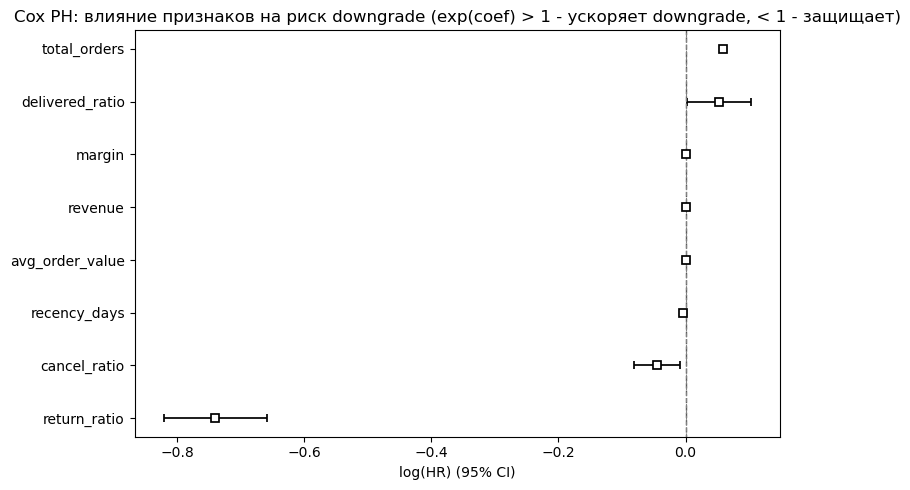

In [43]:
from lifelines import CoxPHFitter

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cox_df, duration_col="duration", event_col="event")
cph.print_summary()

fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title(
    "Cox PH: влияние признаков на риск downgrade "
    "(exp(coef) > 1 - ускоряет downgrade, < 1 - защищает)"
)
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


### Интерпретация Cox PH

Коэффициент `exp(coef)` интерпретируется как **hazard ratio (HR)**:
- `HR > 1`: признак увеличивает риск downgrade и ускоряет деградацию.
- `HR < 1`: признак снижает риск downgrade и выступает защитным фактором.
- Если доверительный интервал пересекает 1 на exp-scale, признак статистически менее устойчив.

Эта модель отвечает на вопрос: **какие поведенческие и финансовые характеристики
клиента в первом наблюдаемом квартале влияют на скорость его перехода в более слабый кластер?**


### AFT (Accelerated Failure Time, Weibull)

<lifelines.WeibullAFTFitter: fitted with 288943 total observations, 267593 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
   number of observations = 288943
number of events observed = 21350
           log-likelihood = -75441.07
         time fit was run = 2026-04-21 17:14:37 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                        
lambda_ avg_order_value -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
        cancel_ratio     0.06      1.06      0.02            0.03            0.09                1.03                1.10
        delivered_ratio -0.04      0.96      0.02           -0.09           -0.00                0.92                1.00
        margin          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        recency_days     0.00      1.00      0.00            0.00            0.00                1.00                1.00
        return_ratio     0.84      2.32      0.04            0.77            0.91                2.16                2.49
        revenue         -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
        total_orders    -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98
        Intercept        1.92      6.82      0.02            1.87            1.97                6.51                7.14
rho_    Intercept        0.43      1.54      0.00            0.43            0.44                1.53                1.56

                         cmp to      z      p  -log2(p)
param   covariate                                      
lambda_ avg_order_value    0.00  -0.47   0.64      0.64
        cancel_ratio       0.00   4.09 <0.005     14.51
        delivered_ratio    0.00  -2.01   0.04      4.50
        margin             0.00 -20.93 <0.005    320.85
        recency_days       0.00  26.10 <0.005    496.25
        return_ratio       0.00  23.36 <0.005    398.38
        revenue            0.00  -7.49 <0.005     43.75
        total_orders       0.00 -14.30 <0.005    151.59
        Intercept          0.00  81.28 <0.005       inf
rho_    Intercept          0.00  98.61 <0.005       inf
---
Concordance = 0.66
AIC = 150902.13
log-likelihood ratio test = -7273.09 on 8 df
-log2(p) of ll-ratio test = -0.00

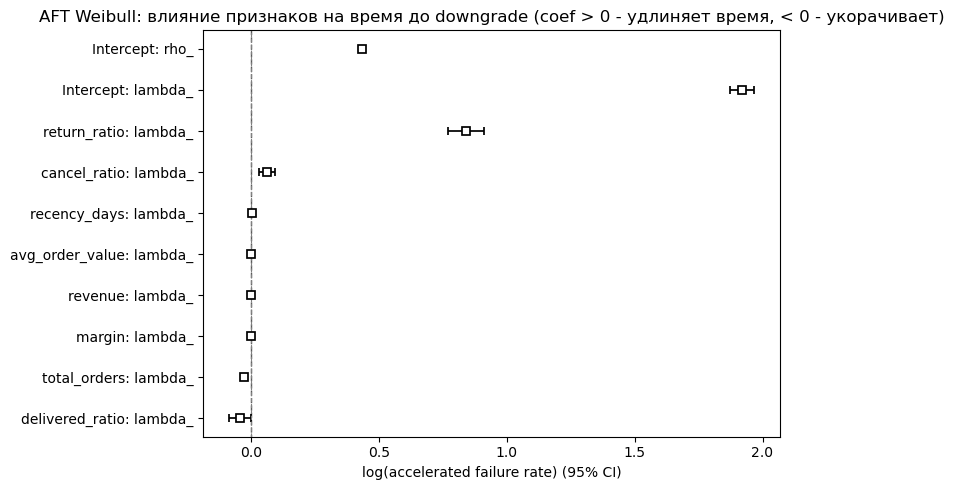

In [44]:
from lifelines import WeibullAFTFitter

aft = WeibullAFTFitter(penalizer=0.1)
aft.fit(cox_df, duration_col="duration", event_col="event")
aft.print_summary()

fig, ax = plt.subplots(figsize=(8, 5))
aft.plot(ax=ax)
ax.set_title(
    "AFT Weibull: влияние признаков на время до downgrade "
    "(coef > 0 - удлиняет время, < 0 - укорачивает)"
)
ax.axvline(0, color="grey", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()


In [45]:
# Медианное предсказанное время до downgrade по каждому клиенту
cox_df["median_cox"] = cph.predict_median(cox_df)
cox_df["median_aft"] = aft.predict_median(cox_df)

print("Распределение предсказанного медианного времени до downgrade (кварталов):")
print(cox_df[["median_cox", "median_aft"]].describe().round(2))


Распределение предсказанного медианного времени до downgrade (кварталов):
       median_cox  median_aft
count    288943.0   288943.00
mean          inf        5.74
std           NaN        1.00
min           1.0        0.11
25%           NaN        5.13
50%           NaN        5.66
75%           NaN        6.27
max           inf       13.66


### Сравнение Cox и AFT

| Модель | Что оценивает | Интерпретация коэффициента |
|--------|--------------|---------------------------|
| **Cox PH** | Мгновенный риск (hazard) | `HR > 1` -> клиент быстрее деградирует |
| **AFT Weibull** | Время до события | `coef > 0` -> клиент дольше остается без downgrade |

Обе survival-модели дополняют бинарную классификацию downgrade:
- Классификаторы отвечают на вопрос **«произойдет ли downgrade?»**
- Survival-подход отвечает на вопрос **«как скоро это произойдет?»**


# Бизнес-применение модели: система раннего предупреждения

Модель отвечает на три управленческих вопроса:

1. **Кого спасать** — скоринг риска (`p_downgrade`)
2. **Чем спасать** — дифференцированные стратегии по рангам кластеров
3. **Сколько денег это сохранит** — expected margin loss

Управленческий контур: **cluster rank -> p_downgrade -> expected loss -> действие -> валидация**


## Блок 0. Сборка скоринговой таблицы (LightGBM)

In [39]:
import pandas as pd
import numpy as np

test_scores_lgbm = test_km[[
    "Телефон_new", "quarter", "cluster_id", "cluster_rank", "margin", "revenue"
]].copy()
test_scores_lgbm["cluster_rank"] = pd.to_numeric(test_scores_lgbm["cluster_rank"], errors="coerce")
test_scores_lgbm["p_downgrade"] = y_prob_lgbm

test_scores_lgbm["cluster_label"] = test_scores_lgbm["cluster_rank"].apply(
    lambda x: f"Rank {int(x)}" if pd.notna(x) else "Unknown"
)
rank_order = sorted(test_scores_lgbm["cluster_rank"].dropna().astype(int).unique().tolist())

base_rate_by_rank = (
    train_km.assign(cluster_rank=pd.to_numeric(train_km["cluster_rank"], errors="coerce"))
    .groupby("cluster_rank")["downgrade"].mean()
    .sort_index()
)
test_scores_lgbm["base_rate"] = test_scores_lgbm["cluster_rank"].map(base_rate_by_rank)

test_scores_lgbm["p_pct_within_seg"] = (
    test_scores_lgbm.groupby("cluster_rank")["p_downgrade"]
    .rank(pct=True, method="average")
)

print("Базовая частота downgrade по rank кластера (train):")
print(base_rate_by_rank.round(3).to_string())


Базовая частота downgrade по rank кластера (train):
cluster_rank
0    0.000
1    0.003
2    0.103
3    0.077
4    0.100
5    0.263
6    0.374
7    0.544
8    0.766
9    0.875


In [40]:
test_scores_lgbm.head()

,Телефон_new,quarter,cluster_id,cluster_rank,margin,revenue,p_downgrade,cluster_label,base_rate,p_pct_within_seg
0,55525753-57524855525273,2017Q3,6,4,416.53,5032.0,0.152305,Rank 4,0.100260,0.441851
1,55575054-53535254555577,2017Q3,6,4,2359.72,6602.0,0.140283,Rank 4,0.100260,0.356324
2,55575054-53535348495770,2017Q3,8,6,128.00,1980.0,0.519255,Rank 6,0.374067,0.230556
3,55575054-53535348534978,2017Q3,6,4,1979.29,14625.0,0.093743,Rank 4,0.100260,0.078098
4,55575054-53535348554873,2017Q3,6,4,-152.07,12162.0,0.080818,Rank 4,0.100260,0.033319


### Структурное смещение p_downgrade между сегментами (LightGBM)

В K-means-версии вместо RFM-сегментов используется `cluster_rank`.
Raw-вероятности могут системно отличаться между рангами кластеров,
поэтому для честной приоритизации полезно нормировать риск
внутри каждого ранга через процентиль `p_pct_within_seg`.


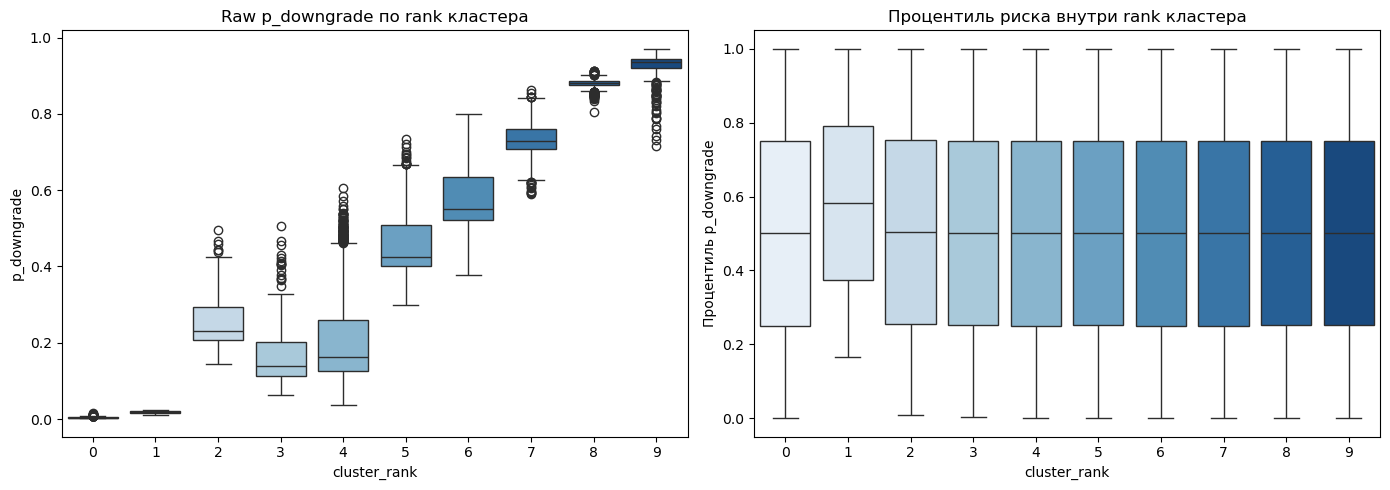

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette("Blues", n_colors=max(len(rank_order), 3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=test_scores_lgbm,
    x="cluster_rank",
    y="p_downgrade",
    order=rank_order,
    ax=axes[0],
    palette=palette,
)
axes[0].set_title("Raw p_downgrade по rank кластера")
axes[0].set_xlabel("cluster_rank")
axes[0].set_ylabel("p_downgrade")

sns.boxplot(
    data=test_scores_lgbm,
    x="cluster_rank",
    y="p_pct_within_seg",
    order=rank_order,
    ax=axes[1],
    palette=palette,
)
axes[1].set_title("Процентиль риска внутри rank кластера")
axes[1].set_xlabel("cluster_rank")
axes[1].set_ylabel("Процентиль p_downgrade")

plt.tight_layout()
plt.show()


## Блок 1. Early Warning System — скоринг риска (LightGBM)

| p_pct_within_seg | Действие |
|---|---|
| < 0.50 | Мониторинг, без вмешательства |
| 0.50 - 0.75 | Автоматические касания (email / push) |
| 0.75 - 0.90 | Персонализированная retention-коммуникация |
| >= 0.90 | Приоритетная кампания с дорогим стимулом |


In [42]:
def assign_policy(p_pct):
    if p_pct < 0.50:
        return "0. Мониторинг"
    if p_pct < 0.75:
        return "1. Email / Push"
    if p_pct < 0.90:
        return "2. Персонализированная коммуникация"
    return "3. Приоритетная кампания"


test_scores_lgbm["action_tier"] = test_scores_lgbm["p_pct_within_seg"].apply(assign_policy)

tier_summary_lgbm = (
    test_scores_lgbm.groupby("action_tier")
    .agg(
        n_клиентов=("Телефон_new", "count"),
        avg_p_raw=("p_downgrade", "mean"),
        avg_p_pct=("p_pct_within_seg", "mean"),
    )
    .round(3)
)
print(tier_summary_lgbm.to_string())


                                     n_клиентов  avg_p_raw  avg_p_pct
action_tier                                                          
0. Мониторинг                              7611      0.348      0.250
1. Email / Push                            3815      0.414      0.625
2. Персонализированная коммуникация        2287      0.467      0.825
3. Приоритетная кампания                   1531      0.536      0.950


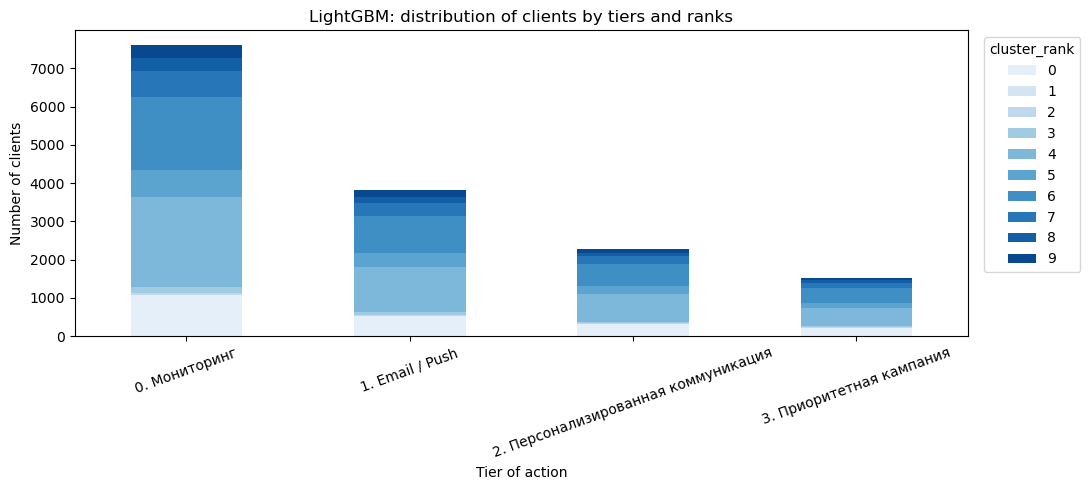

In [43]:
tier_seg_lgbm = (
    test_scores_lgbm.groupby(["action_tier", "cluster_rank"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=rank_order, fill_value=0)
)

fig, ax = plt.subplots(figsize=(11, 5))
tier_seg_lgbm.plot(kind="bar", stacked=True, ax=ax, color=palette)
ax.set_title("LightGBM: distribution of clients by tiers and ranks")
ax.set_xlabel("Tier of action")
ax.set_ylabel("Number of clients")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="cluster_rank", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Блок 2. Expected Margin Loss — приоритизация бюджета (LightGBM)

In [44]:
test_scores_lgbm["expected_loss"] = (
    test_scores_lgbm["p_downgrade"] * test_scores_lgbm["margin"].clip(lower=0)
)

top_loss_lgbm = (
    test_scores_lgbm.sort_values("expected_loss", ascending=False)
    .head(20)[[
        "Телефон_new", "cluster_rank", "p_downgrade", "p_pct_within_seg",
        "margin", "expected_loss"
    ]]
)

print(
    f"Суммарный expected margin loss (тест, LightGBM): "
    f"{test_scores_lgbm['expected_loss'].sum():,.0f} руб."
)
print("\nТоп-10 клиентов по expected loss:")
print(top_loss_lgbm.head(10).to_string(index=False))


Суммарный expected margin loss (тест, LightGBM): 7,042,981 руб.

Топ-10 клиентов по expected loss:
            Телефон_new  cluster_rank  p_downgrade  p_pct_within_seg   margin  expected_loss
55574948-48524850524970             9     0.904812          0.123328 16609.00   15028.022275
55574955-49494949525679             9     0.848078          0.031204 17544.85   14879.407623
55575050-49515055494975             9     0.931411          0.420505 15845.15   14758.339917
55574949-52485350535378             9     0.917041          0.197623 16078.26   14744.421964
55575054-51494857495774             9     0.880504          0.056464 16615.50   14630.022060
55574854-51485556525378             9     0.944221          0.742942 14990.22   14154.078738
55574955-52494848545075             9     0.862304          0.041605 15664.34   13507.429690
55574948-50525455564870             9     0.949417          0.817236 13909.26   13205.690642
55574851-54495754565078             9     0.821016          0.01

### Override по финансовому весу (Вариант Б)

Клиенты с `expected_loss` в топ-10% всей базы получают минимум тир 2 вне зависимости от перцентиля внутри сегмента.
Это защищает финансово важных клиентов, которые иначе выпали бы в «Мониторинг» из-за низкого p_pct внутри высокорискованного сегмента.

In [45]:
# Порог: топ-10% по expected_loss
override_threshold = test_scores_lgbm["expected_loss"].quantile(0.90)

tier_order = {
    "0. Мониторинг": 0,
    "1. Email / Push": 1,
    "2. Персонализированная коммуникация": 2,
    "3. Приоритетная кампания": 3,
}
tier_by_order = {v: k for k, v in tier_order.items()}

# Сохраняем исходный тир, применяем override
test_scores_lgbm["action_tier_base"] = test_scores_lgbm["action_tier"]

def apply_override(row):
    current = tier_order[row["action_tier"]]
    if row["expected_loss"] >= override_threshold:
        return tier_by_order[max(current, 2)]
    return row["action_tier"]

test_scores_lgbm["action_tier"] = test_scores_lgbm.apply(apply_override, axis=1)

# Статистика
overridden = test_scores_lgbm[
    test_scores_lgbm["action_tier"] != test_scores_lgbm["action_tier_base"]
]
print(f"Override threshold (топ-10% expected_loss): {override_threshold:,.0f} руб.")
print(f"Клиентов с повышенным тиром: {len(overridden)}")
print()

comparison = pd.DataFrame({
    "До override": test_scores_lgbm["action_tier_base"].value_counts().sort_index(),
    "После override": test_scores_lgbm["action_tier"].value_counts().sort_index(),
}).fillna(0).astype(int)
comparison["Изменение"] = comparison["После override"] - comparison["До override"]
print(comparison.to_string())
print()

print("Топ-10 клиентов с повышенным тиром:")
print(
    overridden[["Телефон_new", "cluster_rank", "action_tier_base", "action_tier",
                "p_downgrade", "p_pct_within_seg", "margin", "expected_loss"]]
    .sort_values("expected_loss", ascending=False)
    .head(10)
    .to_string(index=False)
)

Override threshold (топ-10% expected_loss): 910 руб.
Клиентов с повышенным тиром: 989

                                     До override  После override  Изменение
0. Мониторинг                               7611            6994       -617
1. Email / Push                             3815            3443       -372
2. Персонализированная коммуникация         2287            3276        989
3. Приоритетная кампания                    1531            1531          0

Топ-10 клиентов с повышенным тиром:
            Телефон_new  cluster_rank action_tier_base                         action_tier  p_downgrade  p_pct_within_seg   margin  expected_loss
55574948-48524850524970             9    0. Мониторинг 2. Персонализированная коммуникация     0.904812          0.123328 16609.00   15028.022275
55574955-49494949525679             9    0. Мониторинг 2. Персонализированная коммуникация     0.848078          0.031204 17544.85   14879.407623
55575050-49515055494975             9    0. Мониторинг 2. 

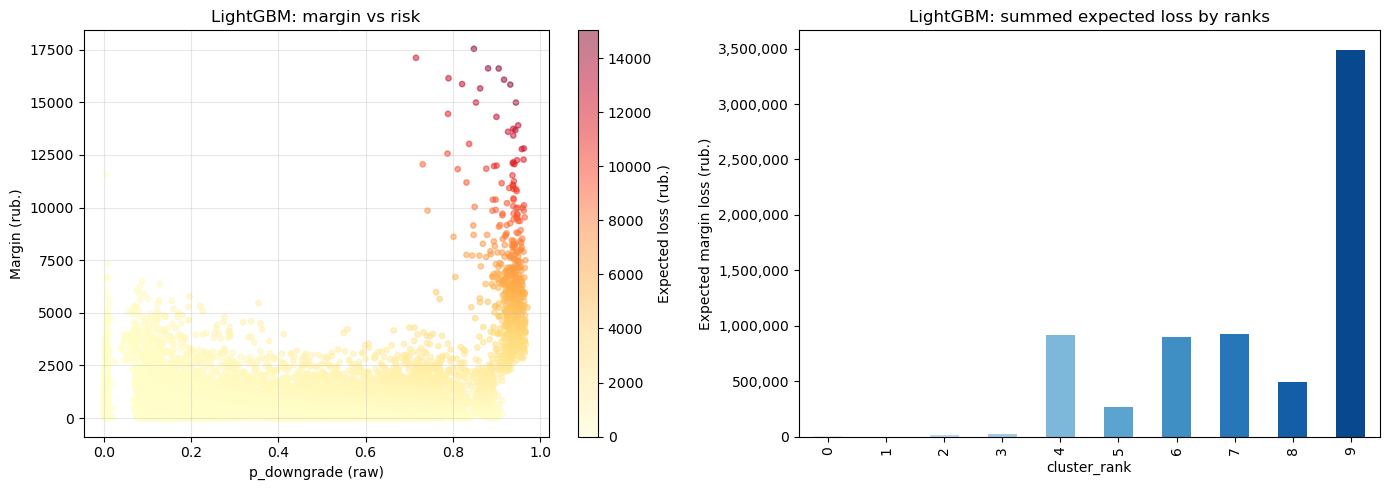

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    test_scores_lgbm["p_downgrade"],
    test_scores_lgbm["margin"].clip(lower=0),
    c=test_scores_lgbm["expected_loss"],
    cmap="YlOrRd",
    alpha=0.5,
    s=15,
)
plt.colorbar(sc, ax=axes[0], label="Expected loss (rub.)")
axes[0].set_xlabel("p_downgrade (raw)")
axes[0].set_ylabel("Margin (rub.)")
axes[0].set_title("LightGBM: margin vs risk")
axes[0].grid(True, alpha=0.3)

rank_loss_lgbm = (
    test_scores_lgbm.groupby("cluster_rank")["expected_loss"]
    .sum()
    .reindex(rank_order)
)
rank_loss_lgbm.plot(kind="bar", ax=axes[1], color=palette)
axes[1].set_title("LightGBM: summed expected loss by ranks")
axes[1].set_xlabel("cluster_rank")
axes[1].set_ylabel("Expected margin loss (rub.)")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.tight_layout()
plt.show()


## Блок 3. Стратегии по сегментам (LightGBM)

In [45]:
intervention_zone_lgbm = test_scores_lgbm[
    test_scores_lgbm["p_pct_within_seg"] >= 0.50
].copy()

rank_strategy_lgbm = (
    intervention_zone_lgbm.groupby("cluster_rank")
    .agg(
        n_клиентов=("Телефон_new", "count"),
        avg_p_raw=("p_downgrade", "mean"),
        avg_p_pct=("p_pct_within_seg", "mean"),
        total_expected_loss=("expected_loss", "sum"),
    )
    .reindex(rank_order)
    .dropna(how="all")
    .round(3)
)
if not rank_strategy_lgbm.empty:
    rank_strategy_lgbm["total_expected_loss"] = (
        rank_strategy_lgbm["total_expected_loss"].map("{:,.0f}".format)
    )

print("Клиенты в зоне вмешательства по rank кластера (LightGBM):")
print(rank_strategy_lgbm.to_string())


Клиенты в зоне вмешательства по rank кластера (LightGBM):
              n_клиентов  avg_p_raw  avg_p_pct total_expected_loss
cluster_rank                                                      
0                   1067      0.005      0.750               7,049
1                      4      0.021      0.750                 104
2                     66      0.316      0.750              10,019
3                    149      0.227      0.750              18,345
4                   2357      0.277      0.750             621,534
5                    721      0.527      0.750             181,314
6                   1897      0.644      0.750             586,897
7                    695      0.767      0.749             497,098
8                    340      0.887      0.751             257,409
9                    337      0.947      0.750           1,820,722


## Блок 4. SHAP — prescriptive слой (LightGBM)

In [47]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("shap") is None:
    print("Installing shap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "--quiet"])
else:
    print("shap is already installed.")


shap is already installed.


SHAP values LightGBM (downgrade). Shape: (15244, 36)


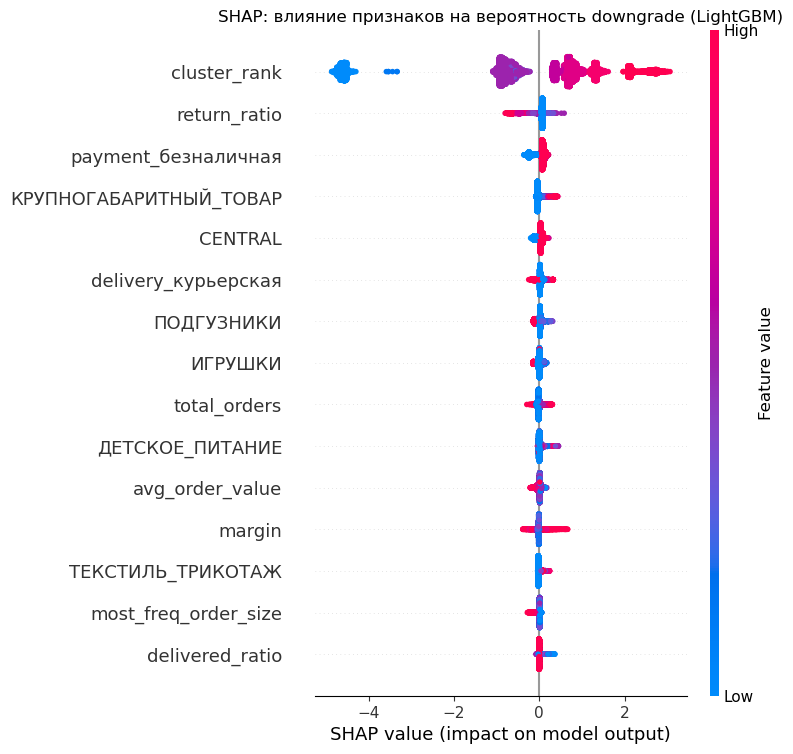

In [48]:
import shap

explainer_lgbm = shap.TreeExplainer(lgbm_bin)
shap_raw_lgbm = explainer_lgbm.shap_values(X_test_bin)

# Совместимость версий SHAP для бинарного классификатора
if isinstance(shap_raw_lgbm, list):
    shap_lgbm_class1 = shap_raw_lgbm[1]
elif np.ndim(shap_raw_lgbm) == 3:
    shap_lgbm_class1 = shap_raw_lgbm[:, :, 1]
else:
    shap_lgbm_class1 = shap_raw_lgbm

print("SHAP values LightGBM (downgrade). Shape:", shap_lgbm_class1.shape)

shap.summary_plot(shap_lgbm_class1, X_test_bin, max_display=15, show=False)
plt.title("SHAP: влияние признаков на вероятность downgrade (LightGBM)")
plt.show()


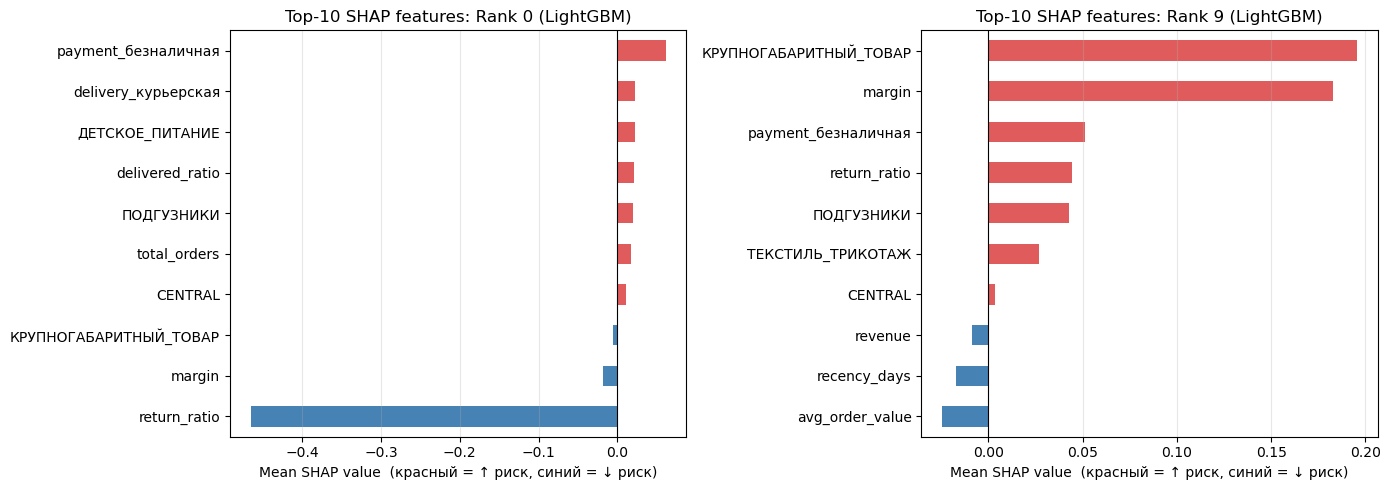

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

available_ranks = sorted(test_scores_lgbm["cluster_rank"].dropna().astype(int).unique().tolist())
selected_ranks = available_ranks[:1] + available_ranks[-1:] if available_ranks else []
selected_ranks = list(dict.fromkeys(selected_ranks))

for ax, rank in zip(axes, selected_ranks):
    mask = test_scores_lgbm["cluster_rank"].fillna(-1).astype(int).values == rank
    if mask.sum() < 5:
        ax.set_visible(False)
        continue

    # Топ-10 по важности (|SHAP|), но рисуем знаковые значения
    top_features = (
        pd.Series(np.abs(shap_lgbm_class1[mask]).mean(axis=0), index=X_test_bin.columns)
        .sort_values(ascending=False)
        .iloc[1:11]
        .index
    )
    mean_shap_signed = (
        pd.Series(shap_lgbm_class1[mask].mean(axis=0), index=X_test_bin.columns)
        [top_features]
        .sort_values(ascending=True)
    )

    bar_colors = ["#e05c5c" if v > 0 else "steelblue" for v in mean_shap_signed]
    mean_shap_signed.plot(kind="barh", ax=ax, color=bar_colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Top-10 SHAP features: Rank {rank} (LightGBM)")
    ax.set_xlabel("Mean SHAP value  (красный = ↑ риск, синий = ↓ риск)")
    ax.grid(True, axis="x", alpha=0.3)

for ax in axes[len(selected_ranks):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## Блок 4б. Персонализированные рекомендации: топ-10 клиентов по Expected Loss + SHAP

Топ-10 клиентов по expected loss:
            Телефон_new  cluster_rank                         action_tier  p_downgrade  p_pct_within_seg   margin  expected_loss
55574948-48524850524970             9 2. Персонализированная коммуникация     0.904812          0.123328 16609.00   15028.022275
55574955-49494949525679             9 2. Персонализированная коммуникация     0.848078          0.031204 17544.85   14879.407623
55575050-49515055494975             9 2. Персонализированная коммуникация     0.931411          0.420505 15845.15   14758.339917
55574949-52485350535378             9 2. Персонализированная коммуникация     0.917041          0.197623 16078.26   14744.421964
55575054-51494857495774             9 2. Персонализированная коммуникация     0.880504          0.056464 16615.50   14630.022060
55574854-51485556525378             9 2. Персонализированная коммуникация     0.944221          0.742942 14990.22   14154.078738
55574955-52494848545075             9 2. Персонализированная ко

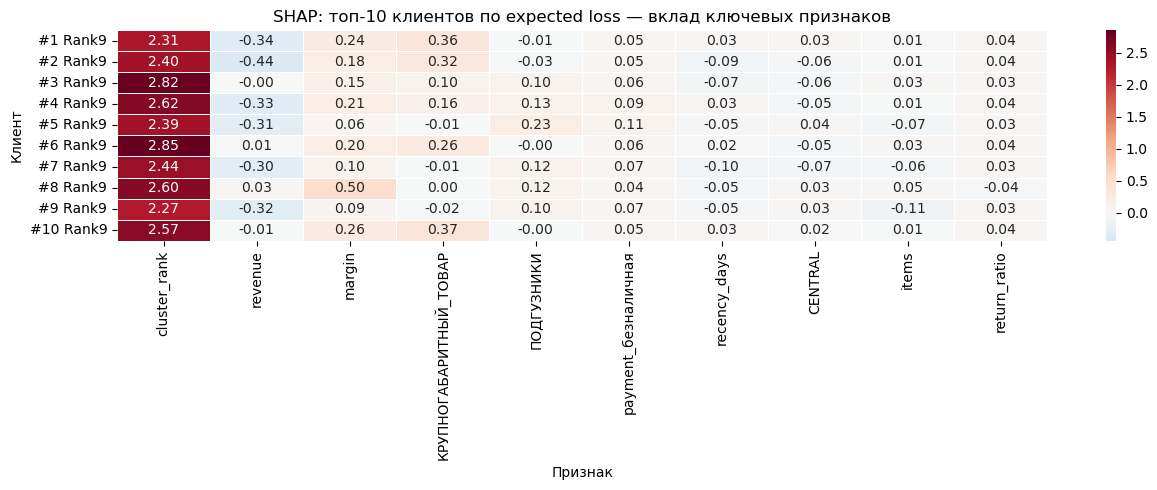

In [49]:
# Топ-10 клиентов по expected loss
top10 = (
    test_scores_lgbm
    .sort_values("expected_loss", ascending=False)
    .head(10)
    .copy()
)

print("Топ-10 клиентов по expected loss:")
print(top10[["Телефон_new", "cluster_rank", "action_tier", "p_downgrade", "p_pct_within_seg", "margin", "expected_loss"]]
      .to_string(index=False))
print()

# Позиции этих клиентов в X_test_bin (по индексу DataFrame)
top10_positions = [X_test_bin.index.get_loc(idx) for idx in top10.index]
shap_top10 = shap_lgbm_class1[top10_positions]  # (10, n_features)

# Для каждого клиента — топ-5 SHAP-признаков
print("=" * 70)
for i, (df_idx, row) in enumerate(top10.iterrows()):
    shap_series = pd.Series(shap_top10[i], index=X_test_bin.columns)
    top5 = shap_series.abs().sort_values(ascending=False).head(5)
    print(f"Клиент: {row['Телефон_new']}  |  Rank {int(row['cluster_rank'])}  |  {row['action_tier']}")
    print(f"  p_downgrade={row['p_downgrade']:.3f}  |  margin={row['margin']:,.0f} руб.  |  expected_loss={row['expected_loss']:,.0f} руб.")
    print("  Топ-5 признаков (SHAP):")
    for feat in top5.index:
        val = shap_series[feat]
        direction = "+" if val > 0 else "-"
        print(f"    {direction} {feat}: {val:+.4f}")
print("=" * 70)

# Визуализация: тепловая карта SHAP топ-10 клиентов
import matplotlib.pyplot as plt
import seaborn as sns

# Топ-10 признаков по средней важности для этих 10 клиентов
mean_abs_shap = pd.Series(
    abs(shap_top10).mean(axis=0), index=X_test_bin.columns
).sort_values(ascending=False).head(10)

shap_heatmap = pd.DataFrame(
    shap_top10[:, [X_test_bin.columns.get_loc(f) for f in mean_abs_shap.index]],
    columns=mean_abs_shap.index,
    index=[f"#{i+1} Rank{int(r)}" for i, r in enumerate(top10["cluster_rank"])]
)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(shap_heatmap, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            linewidths=0.5, ax=ax)
ax.set_title("SHAP: топ-10 клиентов по expected loss — вклад ключевых признаков")
ax.set_xlabel("Признак")
ax.set_ylabel("Клиент")
plt.tight_layout()
plt.show()


## Блок 5. Операционный дашборд (LightGBM)

In [50]:
tier_counts_lgbm = test_scores_lgbm["action_tier"].value_counts().sort_index()

summary_lgbm = pd.DataFrame({
    "Тир": tier_counts_lgbm.index,
    "Клиентов": tier_counts_lgbm.values,
    "Доля, %": (tier_counts_lgbm / len(test_scores_lgbm) * 100).round(1).values,
})
print("=== Операционный дашборд — LightGBM ===")
print(summary_lgbm.to_string(index=False))

zone_50_lgbm = test_scores_lgbm[
    test_scores_lgbm["p_pct_within_seg"] >= 0.50
]["expected_loss"].sum()
zone_90_lgbm = test_scores_lgbm[
    test_scores_lgbm["p_pct_within_seg"] >= 0.90
]["expected_loss"].sum()
top_decile_share = (
    zone_90_lgbm / test_scores_lgbm["expected_loss"].sum()
    if test_scores_lgbm["expected_loss"].sum() > 0 else np.nan
)

print(f"\nExpected loss в зоне вмешательства (p_pct >= 0.50): {zone_50_lgbm:>12,.0f} руб.")
print(f"Expected loss в приоритетной кампании (p_pct >= 0.90): {zone_90_lgbm:>12,.0f} руб.")
print(f"Доля потенциальных потерь, сосредоточенная в верхнем дециле риска: {top_decile_share:.1%}")


=== Операционный дашборд — LightGBM ===
                                Тир  Клиентов  Доля, %
                      0. Мониторинг      6994     45.9
                    1. Email / Push      3443     22.6
2. Персонализированная коммуникация      3276     21.5
           3. Приоритетная кампания      1531     10.0

Expected loss в зоне вмешательства (p_pct >= 0.50):    4,000,491 руб.
Expected loss в приоритетной кампании (p_pct >= 0.90):      923,799 руб.
Доля потенциальных потерь, сосредоточенная в верхнем дециле риска: 13.1%
